# Kinase domain alignment and local-delta generation

Este notebook corrige el pipeline activo/inactivo en tres pasos:

1. extrae un dominio catalítico comparable anclado por DFG, HRD, VAIK-Lys y alphaC-Glu;
2. mantiene correspondencia exacta de residuos homólogos y consecutividad real;
3. aprende un delta local con `generated = source + delta_predicho`.

Los pares activo/inactivo son referencias débiles de una distribución, no ground truth único.
El objetivo es diagnóstico y generación de hipótesis, no reconstrucción exacta de un PDB.


In [1]:
from __future__ import annotations

import json, os, sys, math, warnings
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

def find_root(start=Path.cwd()):
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / "data/metadata/kinase_labels.csv").exists():
            return candidate
    raise FileNotFoundError("No se encontró la raíz del proyecto.")

ROOT = find_root()
TRAINING = ROOT / "training"
if str(TRAINING) not in sys.path:
    sys.path.insert(0, str(TRAINING))

import kinase_domain_local_delta as exp

SMOKE = os.getenv("KINASE_DOMAIN_DELTA_SMOKE", "0") == "1"
OUTPUT = (
    Path("/private/tmp/kinase_domain_alignment_local_delta_generation_smoke")
    if SMOKE else ROOT / "outputs/kinase_domain_alignment_local_delta_generation"
)
CHECKPOINTS = OUTPUT / "checkpoints"
METRICS = OUTPUT / "metrics"
FIGURES = OUTPUT / "figures"
EXAMPLES = OUTPUT / "generated_examples"
HTML = OUTPUT / "html"
for directory in (OUTPUT, CHECKPOINTS, METRICS, FIGURES, EXAMPLES, HTML):
    directory.mkdir(parents=True, exist_ok=True)

CONFIG = exp.Config()
if SMOKE:
    CONFIG.epochs = 2
    CONFIG.patience = 2
    CONFIG.batch_size = 4
    CONFIG.num_points = 72
    CONFIG.hidden_dim = 64
    CONFIG.num_layers = 2
    CONFIG.integration_steps = 3
    CONFIG.validation_every = 1
    CONFIG.max_pairs_per_kinase = 2
    CONFIG.guidance_sweep = (0.0, 1.0)

exp.set_seed(CONFIG.seed)
DEVICE = exp.device_name()
exp.save_config(CONFIG, OUTPUT, DEVICE)
sns.set_theme(style="whitegrid")
print("ROOT:", ROOT)
print("DEVICE:", DEVICE)
print("SMOKE:", SMOKE)
print("OUTPUT:", OUTPUT)


ROOT: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada
DEVICE: mps
SMOKE: False
OUTPUT: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/outputs/kinase_domain_alignment_local_delta_generation


/Users/josefinadehan/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga y auditoría del dataset

Se reportan duplicados, conflictos, estados, longitudes y motivos antes de cualquier entrenamiento.


In [2]:
raw = pd.read_csv(ROOT / "data/metadata/kinase_labels.csv")
raw["pdb_id"] = raw.pdb_id.astype(str).str.lower()
raw["conformational_state"] = raw.conformational_state.astype(str).str.lower()
duplicate_rows = int(raw.duplicated("pdb_id").sum())
conflicting_ids = raw.groupby("pdb_id").conformational_state.nunique()
conflicting_ids = set(conflicting_ids[conflicting_ids > 1].index)

domains, domain_metadata, structure_audit, dataset_summary = exp.load_domains(ROOT, CONFIG)
dataset_audit = dataset_summary.assign(
    duplicate_rows=duplicate_rows,
    contradictory_pdb=len(conflicting_ids),
)
dataset_audit.to_csv(METRICS / "dataset_audit.csv", index=False)
domain_metadata.to_csv(METRICS / "domain_metadata.csv", index=False)
structure_audit.to_csv(METRICS / "structure_loading_audit.csv", index=False)

state_by_kinase = pd.crosstab(
    raw[~raw.pdb_id.isin(conflicting_ids)].kinase_name,
    raw[~raw.pdb_id.isin(conflicting_ids)].conformational_state,
)
state_by_kinase.to_csv(METRICS / "state_by_kinase_before_domain_filter.csv")
display(dataset_audit)
display(state_by_kinase.assign(total=state_by_kinase.sum(1)).sort_values("total", ascending=False))


,raw_records,raw_unique_pdb,conflicting_pdb_removed,valid_unique_structures,active,inactive,kinases,duplicate_rows,contradictory_pdb
0,1777,863,15,848,446,402,13,914,15


conformational_state,active,inactive,total
kinase_name,,,
EGFR,214,337,551
BRAF,50,179,229
FGFR1,209,4,213
MET,9,156,165
ABL1,34,104,138
PIK3CA,131,3,134
ALK,91,4,95
KIT,18,51,69
AKT1,38,24,62


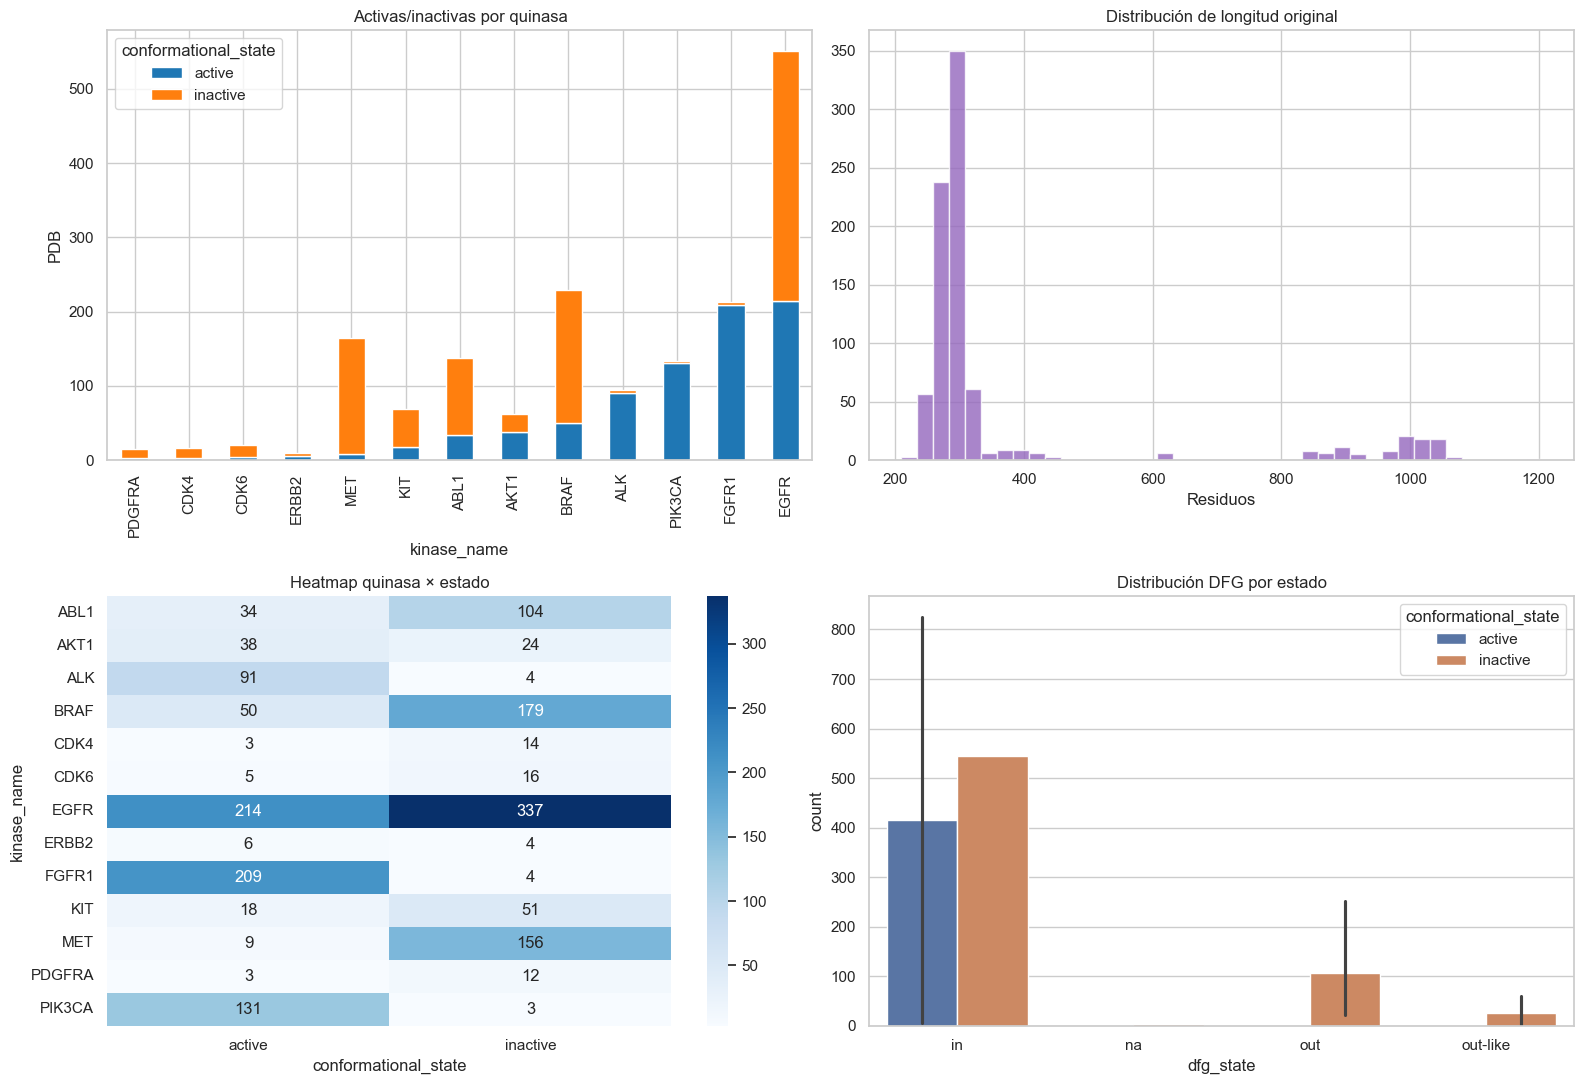

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
state_by_kinase.sort_values(state_by_kinase.columns.tolist()).plot.bar(
    stacked=True, ax=axes[0, 0], color=["tab:blue", "tab:orange"]
)
axes[0, 0].set(title="Activas/inactivas por quinasa", ylabel="PDB")

lengths = domain_metadata.original_length.dropna()
axes[0, 1].hist(lengths, bins=40, color="tab:purple", alpha=0.8)
axes[0, 1].set(title="Distribución de longitud original", xlabel="Residuos")

sns.heatmap(state_by_kinase, annot=True, fmt="g", cmap="Blues", ax=axes[1, 0])
axes[1, 0].set_title("Heatmap quinasa × estado")

motif_counts = (
    raw.groupby(["conformational_state", "dfg_state", "alphac_state"])
    .size().rename("count").reset_index()
)
sns.barplot(data=motif_counts, x="dfg_state", y="count", hue="conformational_state", ax=axes[1, 1])
axes[1, 1].set_title("Distribución DFG por estado")
fig.tight_layout()
fig.savefig(FIGURES / "dataset_audit_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


## 2. Extracción de un dominio quinasa comparable

El recorte se ancla en motivos conservados y evita comparar cadenas completas de ~300 con ~1000
residuos. PIK3CA se conserva como diagnóstico separado si no puede mapearse HRD con confianza.


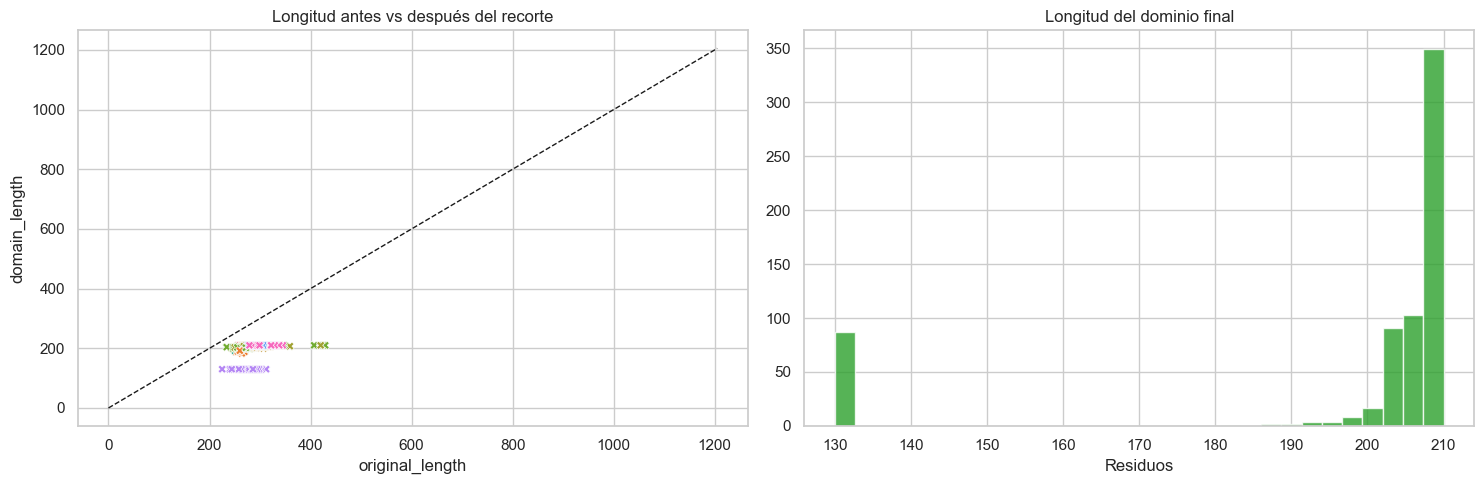

,kinase,discard_reason,count
0,ABL1,"missing_motifs:dfg,hrd",1
1,ABL1,missing_motifs:hrd,2
2,AKT1,"missing_motifs:dfg,hrd",1
3,AKT1,missing_motifs:hrd,32
4,ALK,missing_motifs:dfg,2
5,BRAF,missing_motifs:dfg,5
6,CDK4,missing_motifs:alphac,4
7,CDK4,"missing_motifs:lys,alphac",2
8,EGFR,"missing_motifs:dfg,hrd",1
9,EGFR,"missing_motifs:dfg,hrd,lys,alphac",6


,pdb_id,state,original_length,accepted,discard_reason
737,2rd0,active,997,False,missing_motifs:hrd
738,3hhm,active,1032,False,missing_motifs:hrd
739,3hiz,active,1024,False,missing_motifs:hrd
740,3zim,active,886,False,missing_motifs:hrd
741,4jps,active,999,False,missing_motifs:hrd
742,4l1b,active,994,False,missing_motifs:hrd
743,4l23,active,1014,False,missing_motifs:hrd
744,4l2y,active,991,False,missing_motifs:hrd
745,4ovu,active,1044,False,missing_motifs:hrd
746,4ovv,active,1042,False,missing_motifs:hrd


In [4]:
accepted = domain_metadata.query("accepted").copy()
discarded = domain_metadata.query("not accepted").copy()
discarded.to_csv(METRICS / "discarded_structures.csv", index=False)

clean_full = accepted.copy()
clean_without_pik3ca = accepted.query("kinase != 'PIK3CA'").copy()
clean_pik3ca = domain_metadata.query("kinase == 'PIK3CA'").copy()
clean_full.to_csv(METRICS / "clean_dataset_full.csv", index=False)
clean_without_pik3ca.to_csv(METRICS / "clean_dataset_without_pik3ca.csv", index=False)
clean_pik3ca.to_csv(METRICS / "pik3ca_isolated_diagnostic.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=domain_metadata, x="original_length", y="domain_length",
    hue="kinase", style="accepted", ax=axes[0], legend=False,
)
axes[0].plot([0, domain_metadata.original_length.max()], [0, domain_metadata.original_length.max()], "k--", lw=1)
axes[0].set_title("Longitud antes vs después del recorte")
axes[1].hist(accepted.domain_length, bins=30, color="tab:green", alpha=0.8)
axes[1].set(title="Longitud del dominio final", xlabel="Residuos")
fig.tight_layout()
fig.savefig(FIGURES / "domain_length_before_after.png", dpi=200, bbox_inches="tight")
plt.show()

display(discarded.groupby(["kinase", "discard_reason"]).size().rename("count").reset_index())
display(clean_pik3ca[["pdb_id", "state", "original_length", "accepted", "discard_reason"]].head(20))


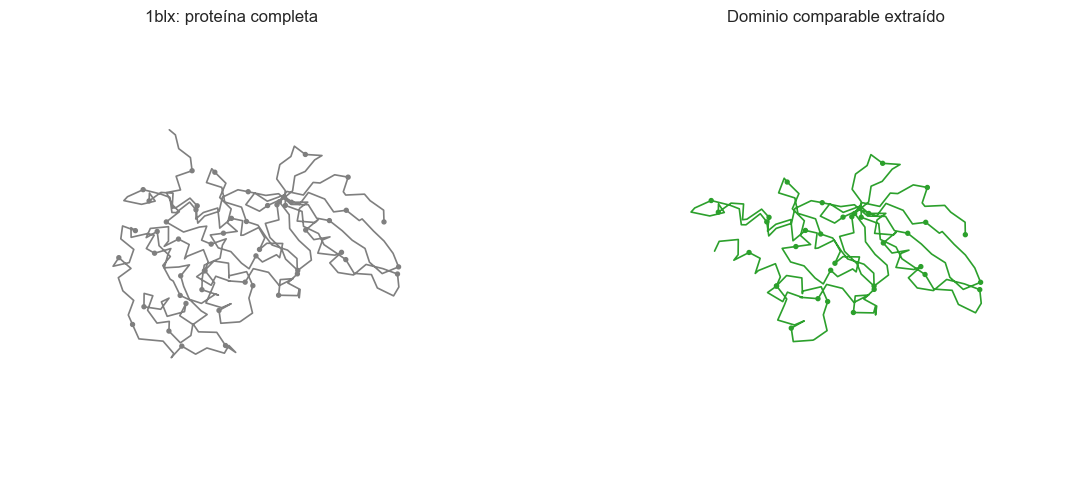

In [5]:
def equal_3d(ax, xyz):
    center = xyz.mean(0)
    radius = max(np.ptp(xyz, axis=0).max() / 2, 1e-6)
    ax.set_xlim(center[0]-radius, center[0]+radius)
    ax.set_ylim(center[1]-radius, center[1]+radius)
    ax.set_zlim(center[2]-radius, center[2]+radius)

def trace(ax, xyz, title, color, alpha=1.0):
    ax.plot(*xyz.T, color=color, alpha=alpha, lw=1.2)
    ax.scatter(*xyz[::6].T, color=color, s=8, alpha=alpha)
    ax.set_title(title); ax.set_axis_off(); equal_3d(ax, xyz)

example_domain = next(domain for values in domains.values() for domain in values if len(domain.structure.residues) > 300)
full_xyz = np.asarray([res.ca for res in example_domain.structure.residues])
domain_xyz = np.asarray(example_domain.coords)
fig = plt.figure(figsize=(13, 5))
trace(fig.add_subplot(1, 2, 1, projection="3d"), full_xyz, f"{example_domain.pdb_id}: proteína completa", "tab:gray")
trace(fig.add_subplot(1, 2, 2, projection="3d"), domain_xyz, "Dominio comparable extraído", "tab:green")
fig.tight_layout()
fig.savefig(FIGURES / "domain_extraction_3d_example.png", dpi=200, bbox_inches="tight")
plt.show()


## 3. Alineamiento y correspondencia exacta

Cada punto conserva índice de dominio, índice original, número PDB y aminoácido. La máscara de
consecutividad es verdadera solo si ambos residuos son consecutivos en source y target.


In [6]:
pair_table, selected_pairs = exp.build_pairs(domains, CONFIG)
pair_table.to_csv(METRICS / "constructed_pairs.csv", index=False)

train_kinases = sorted({domain.kinase for domain in domains["train"]})
KINASE_VOCAB = {"<UNK>": 0, **{name: i + 1 for i, name in enumerate(train_kinases)}}
datasets = {
    split: exp.PairDataset(pairs, CONFIG, KINASE_VOCAB)
    for split, pairs in selected_pairs.items()
}
if SMOKE:
    for split in datasets:
        datasets[split].pairs = datasets[split].pairs[:12]
loaders = {
    split: DataLoader(
        dataset, batch_size=CONFIG.batch_size, shuffle=(split == "train"),
        num_workers=CONFIG.num_workers,
        generator=torch.Generator().manual_seed(CONFIG.seed),
    )
    for split, dataset in datasets.items()
}
domain_lookup = {
    domain.pdb_id: domain for values in domains.values() for domain in values
}

sample_item = datasets["train"][0]
correspondence = pd.DataFrame({
    "aligned_position": np.arange(CONFIG.num_points),
    "source_domain_index": sample_item["source_domain_indices"].numpy(),
    "target_domain_index": sample_item["target_domain_indices"].numpy(),
    "source_original_index": sample_item["source_original_indices"].numpy(),
    "target_original_index": sample_item["target_original_indices"].numpy(),
    "valid": sample_item["mask"].numpy(),
})
correspondence["consecutive_to_next"] = np.r_[sample_item["consecutive_mask"].numpy(), False]
correspondence.to_csv(METRICS / "example_residue_correspondence.csv", index=False)
display(correspondence.head(30))


,aligned_position,source_domain_index,target_domain_index,source_original_index,target_original_index,valid,consecutive_to_next
0,0,0,0,3,0,True,True
1,1,1,1,4,1,True,False
2,2,3,3,6,3,True,True
3,3,4,4,7,4,True,False
4,4,6,6,9,6,True,True
5,5,7,7,10,7,True,False
6,6,9,9,12,9,True,True
7,7,10,10,13,10,True,False
8,8,12,12,15,12,True,True
9,9,13,13,16,13,True,False


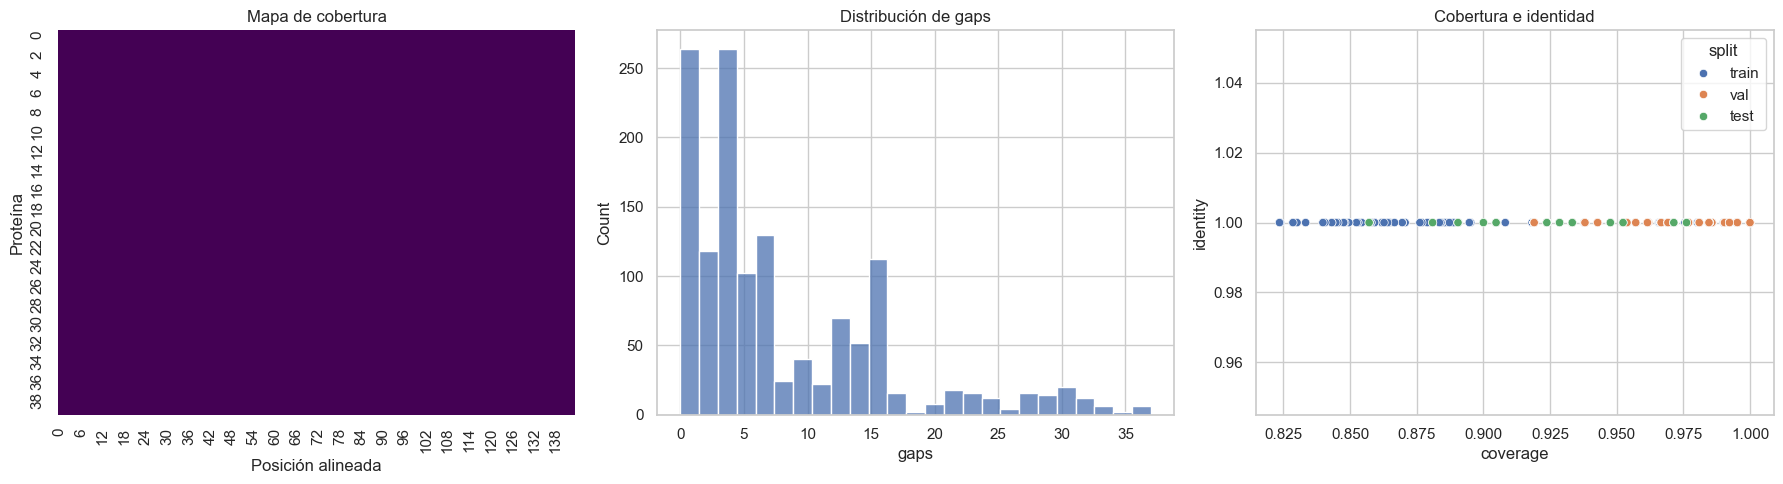

In [7]:
alignment_rows = []
for split, dataset in datasets.items():
    for index in range(len(dataset)):
        item = dataset[index]
        alignment_rows.append({
            "split": split, "source_pdb": item["source_pdb"],
            "target_pdb": item["weak_target_pdb"], "kinase": item["kinase"],
            "coverage": item["coverage"], "identity": item["identity"],
            "gap_fraction": item["gap_fraction"], "gaps": item["gaps"],
            "valid_points": int(item["mask"].sum()),
            "real_consecutive_edges": int(item["consecutive_mask"].sum()),
        })
alignment_audit = pd.DataFrame(alignment_rows)
alignment_audit.to_csv(METRICS / "alignment_audit.csv", index=False)

coverage_matrix = []
labels = []
for index in range(min(40, len(datasets["train"]))):
    item = datasets["train"][index]
    coverage_matrix.append(item["mask"].numpy())
    labels.append(item["source_pdb"])
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.heatmap(np.asarray(coverage_matrix), cmap="viridis", cbar=False, ax=axes[0])
axes[0].set(title="Mapa de cobertura", xlabel="Posición alineada", ylabel="Proteína")
sns.histplot(alignment_audit.gaps, bins=25, ax=axes[1])
axes[1].set_title("Distribución de gaps")
sns.scatterplot(data=alignment_audit, x="coverage", y="identity", hue="split", ax=axes[2])
axes[2].set_title("Cobertura e identidad")
fig.tight_layout()
fig.savefig(FIGURES / "alignment_coverage_and_gaps.png", dpi=200, bbox_inches="tight")
plt.show()


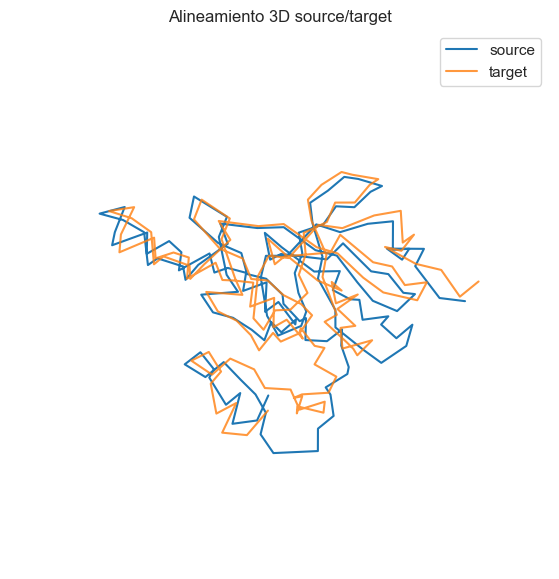

In [8]:
example_pair = datasets["train"][0]
mask = example_pair["mask"].bool()
source_xyz = example_pair["x0"][mask].numpy() * float(example_pair["scale"])
target_xyz = example_pair["x1"][mask].numpy() * float(example_pair["scale"])
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
ax.plot(*source_xyz.T, label="source", color="tab:blue")
ax.plot(*target_xyz.T, label="target", color="tab:orange", alpha=0.8)
ax.legend(); ax.set_axis_off(); ax.set_title("Alineamiento 3D source/target")
equal_3d(ax, np.vstack([source_xyz, target_xyz]))
fig.savefig(FIGURES / "aligned_source_target_3d.png", dpi=200, bbox_inches="tight")
plt.show()


## 4. Regiones funcionales y features locales

Se construyen máscaras para DFG, alphaC, HRD, activation loop, core conservado y resto. Las features
incluyen HRD–DFG, Lys–Glu, Lys–DFG, radios locales, radius of gyration y matriz de distancias.


In [9]:
feature_metadata, feature_matrix = exp.domain_feature_table(domains, CONFIG)
classifier, classifier_report, feature_importance = exp.train_feature_classifier(
    feature_metadata, feature_matrix
)
feature_metadata.to_csv(METRICS / "domain_feature_index.csv", index=False)
np.savez_compressed(METRICS / "domain_features.npz", features=feature_matrix)
classifier_report.to_csv(METRICS / "domain_classifier_report.csv", index=False)
feature_importance.to_csv(METRICS / "feature_importance.csv", index=False)

feature_frame = pd.DataFrame(feature_matrix, columns=exp.feature_names())
feature_frame = pd.concat([feature_metadata.reset_index(drop=True), feature_frame], axis=1)
display(classifier_report)
display(feature_importance.head(12))


,split,samples,balanced_accuracy,roc_auc
0,train,540,0.995130,0.999944
1,val,117,0.691176,0.779739
2,test,11,0.666667,1.000000


,feature,importance
11,hrd_dfg_distance,0.188959
4,dfg_radius,0.148460
3,dfg_mean_distance,0.139940
8,hrd_radius,0.103574
7,hrd_mean_distance,0.102857
13,lys_dfg_distance,0.062207
12,lys_glu_distance,0.045949
5,alphac_mean_distance,0.042956
6,alphac_radius,0.039834
9,activation_loop_mean_distance,0.032203


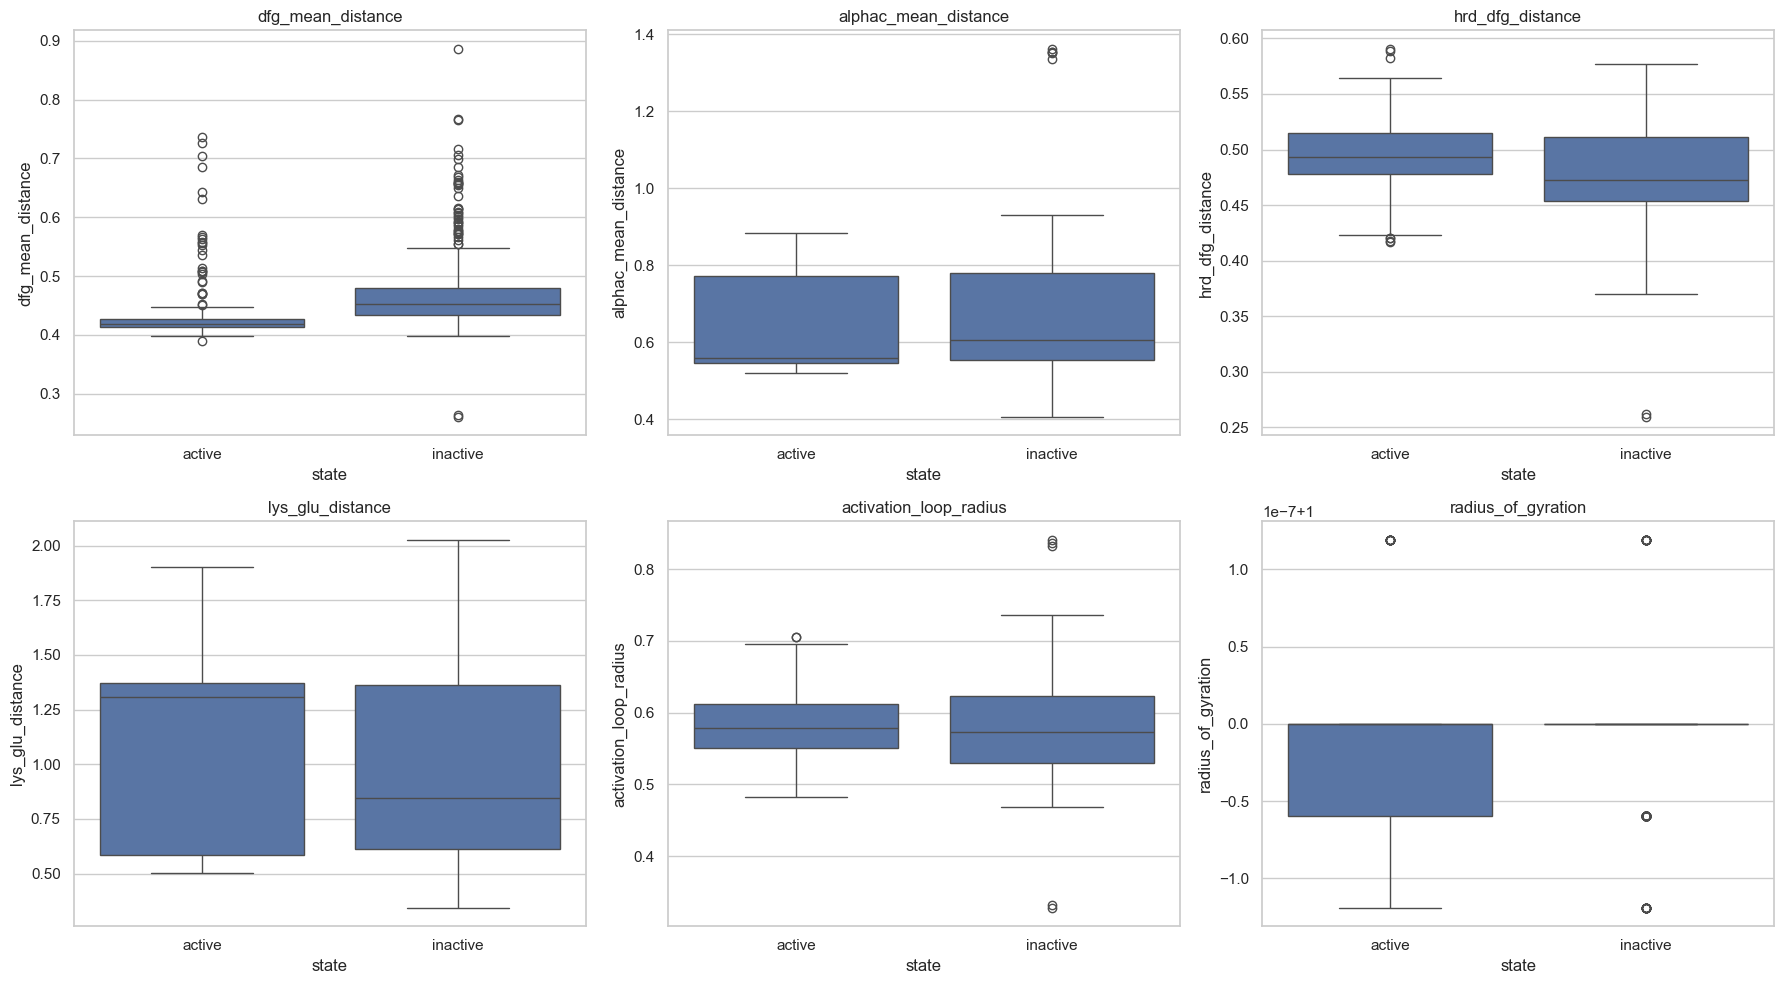

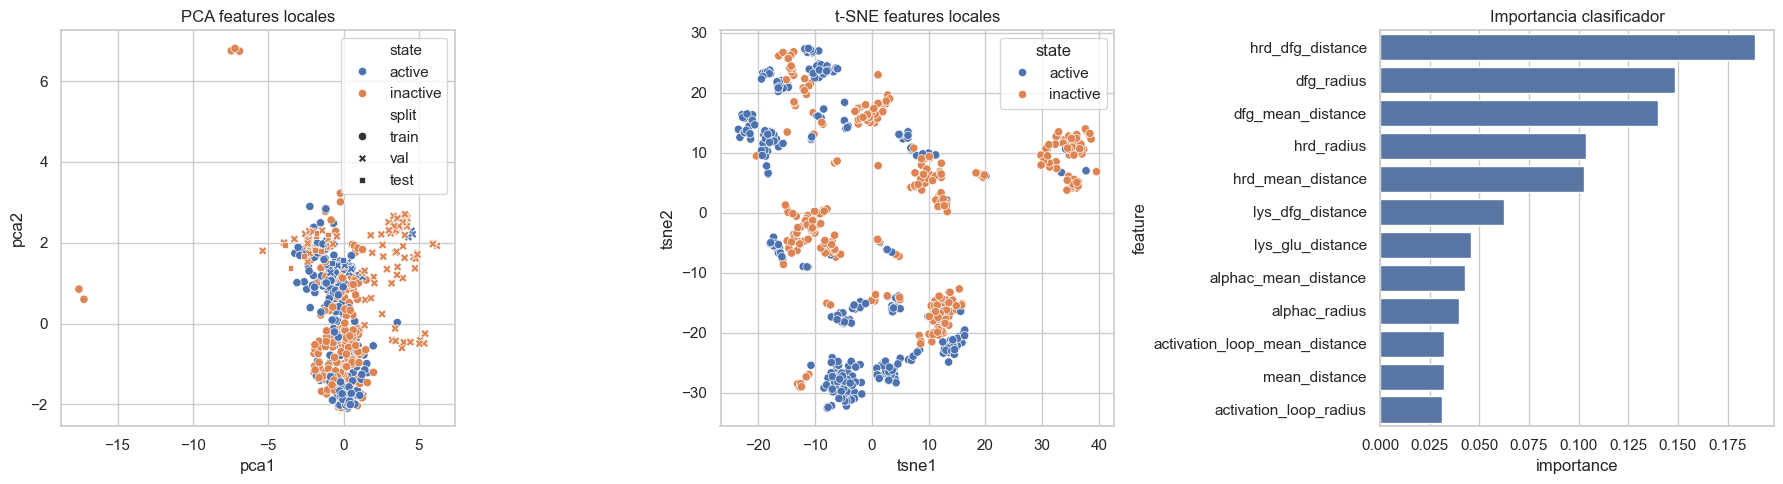

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, name in zip(
    axes.flat,
    ["dfg_mean_distance", "alphac_mean_distance", "hrd_dfg_distance",
     "lys_glu_distance", "activation_loop_radius", "radius_of_gyration"],
):
    sns.boxplot(data=feature_frame, x="state", y=name, ax=ax)
    ax.set_title(name)
fig.tight_layout()
fig.savefig(FIGURES / "local_features_by_state.png", dpi=200, bbox_inches="tight")
plt.show()

scaled = StandardScaler().fit_transform(feature_matrix)
pca = PCA(n_components=2, random_state=CONFIG.seed).fit_transform(scaled)
perplexity = max(2, min(30, len(scaled) // 4))
tsne = TSNE(n_components=2, random_state=CONFIG.seed, perplexity=perplexity).fit_transform(scaled)
projection = feature_metadata[["pdb_id", "kinase", "state", "split"]].copy()
projection[["pca1", "pca2"]] = pca
projection[["tsne1", "tsne2"]] = tsne
projection.to_csv(METRICS / "local_feature_projections.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=projection, x="pca1", y="pca2", hue="state", style="split", ax=axes[0])
sns.scatterplot(data=projection, x="tsne1", y="tsne2", hue="state", ax=axes[1])
sns.barplot(data=feature_importance.head(12), y="feature", x="importance", ax=axes[2])
axes[0].set_title("PCA features locales"); axes[1].set_title("t-SNE features locales")
axes[2].set_title("Importancia clasificador")
fig.tight_layout()
fig.savefig(FIGURES / "local_feature_embedding_and_importance.png", dpi=200, bbox_inches="tight")
plt.show()


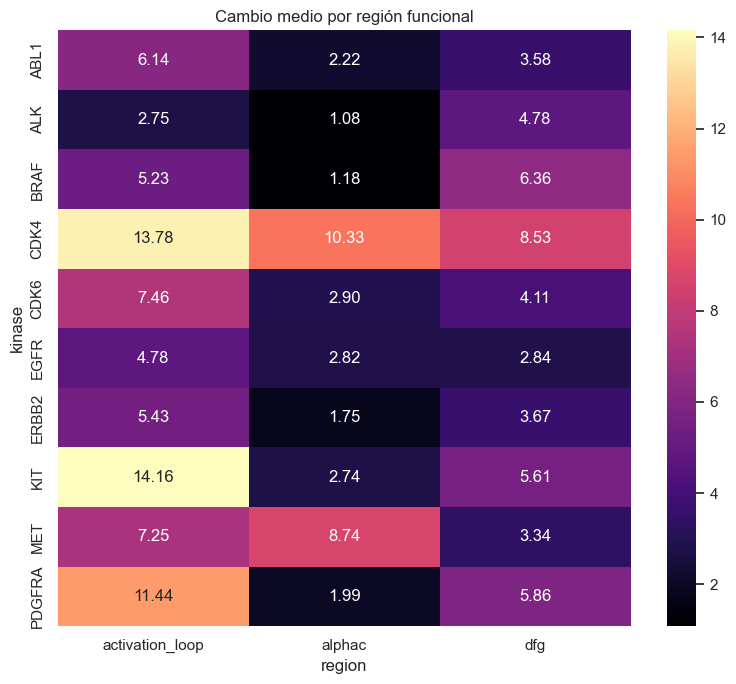

In [11]:
regional_changes = []
for _, row in pair_table.iterrows():
    for region in ("dfg", "alphac", "activation_loop"):
        regional_changes.append({
            "kinase": row.kinase, "direction": row.direction,
            "region": region, "rmsd": row[f"{region}_rmsd"],
        })
regional_changes = pd.DataFrame(regional_changes)
regional_changes["rmsd"] = pd.to_numeric(regional_changes["rmsd"], errors="coerce")
region_map = regional_changes.pivot_table(
    index="kinase", columns="region", values="rmsd", aggfunc="mean"
)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(region_map, annot=True, fmt=".2f", cmap="magma", ax=ax)
ax.set_title("Cambio medio por región funcional")
fig.tight_layout()
fig.savefig(FIGURES / "regional_change_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


## 5. Limpieza y selección

Se comparan dataset completo, filtrado y caso PIK3CA. Los pares con RMSD < 1 Å se marcan ambiguos,
no se presentan como transiciones claras.


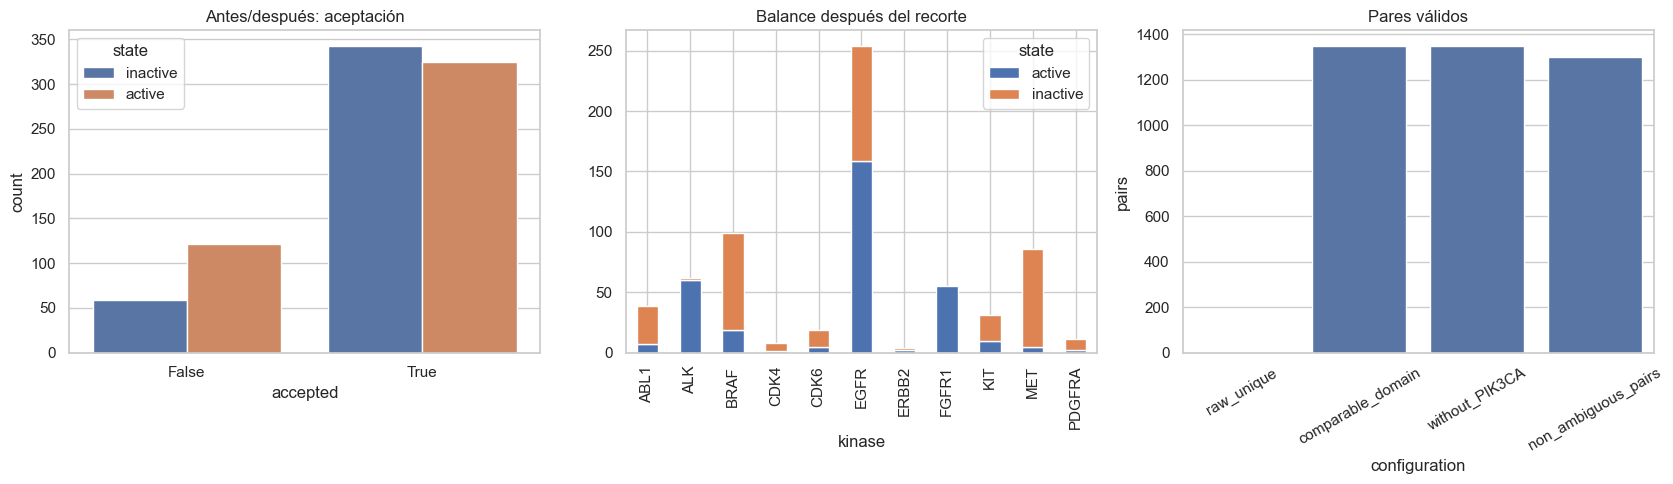

,configuration,structures,pairs
0,raw_unique,863,NaN
1,comparable_domain,668,1350.0
2,without_PIK3CA,668,1350.0
3,non_ambiguous_pairs,668,1300.0


In [12]:
pair_table["valid_geometry_reference"] = True
clean_pairs = pair_table.query("not ambiguous_below_1A").copy()
pair_table.to_csv(METRICS / "all_pairs_with_ambiguity.csv", index=False)
clean_pairs.to_csv(METRICS / "clean_pairs_without_ambiguous.csv", index=False)

comparison = pd.DataFrame([
    {"configuration": "raw_unique", "structures": int(dataset_summary.raw_unique_pdb.iloc[0]), "pairs": np.nan},
    {"configuration": "comparable_domain", "structures": len(accepted), "pairs": len(pair_table)},
    {"configuration": "without_PIK3CA", "structures": len(clean_without_pik3ca), "pairs": len(pair_table.query("kinase != 'PIK3CA'"))},
    {"configuration": "non_ambiguous_pairs", "structures": len(accepted), "pairs": len(clean_pairs)},
])
comparison.to_csv(METRICS / "cleaning_configuration_comparison.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
sns.countplot(data=domain_metadata, x="accepted", hue="state", ax=axes[0])
axes[0].set_title("Antes/después: aceptación")
accepted_counts = pd.crosstab(accepted.kinase, accepted.state)
accepted_counts.plot.bar(stacked=True, ax=axes[1])
axes[1].set_title("Balance después del recorte")
sns.barplot(data=comparison, x="configuration", y="pairs", ax=axes[2])
axes[2].tick_params(axis="x", rotation=30); axes[2].set_title("Pares válidos")
fig.tight_layout()
fig.savefig(FIGURES / "cleaning_before_after.png", dpi=200, bbox_inches="tight")
plt.show()
display(comparison)


## 6. Pares y objetivos débiles

Los pares se construyen dentro de la misma quinasa en ambas direcciones y se describen por cambio
global, DFG, alphaC, activation loop, cobertura y calidad.


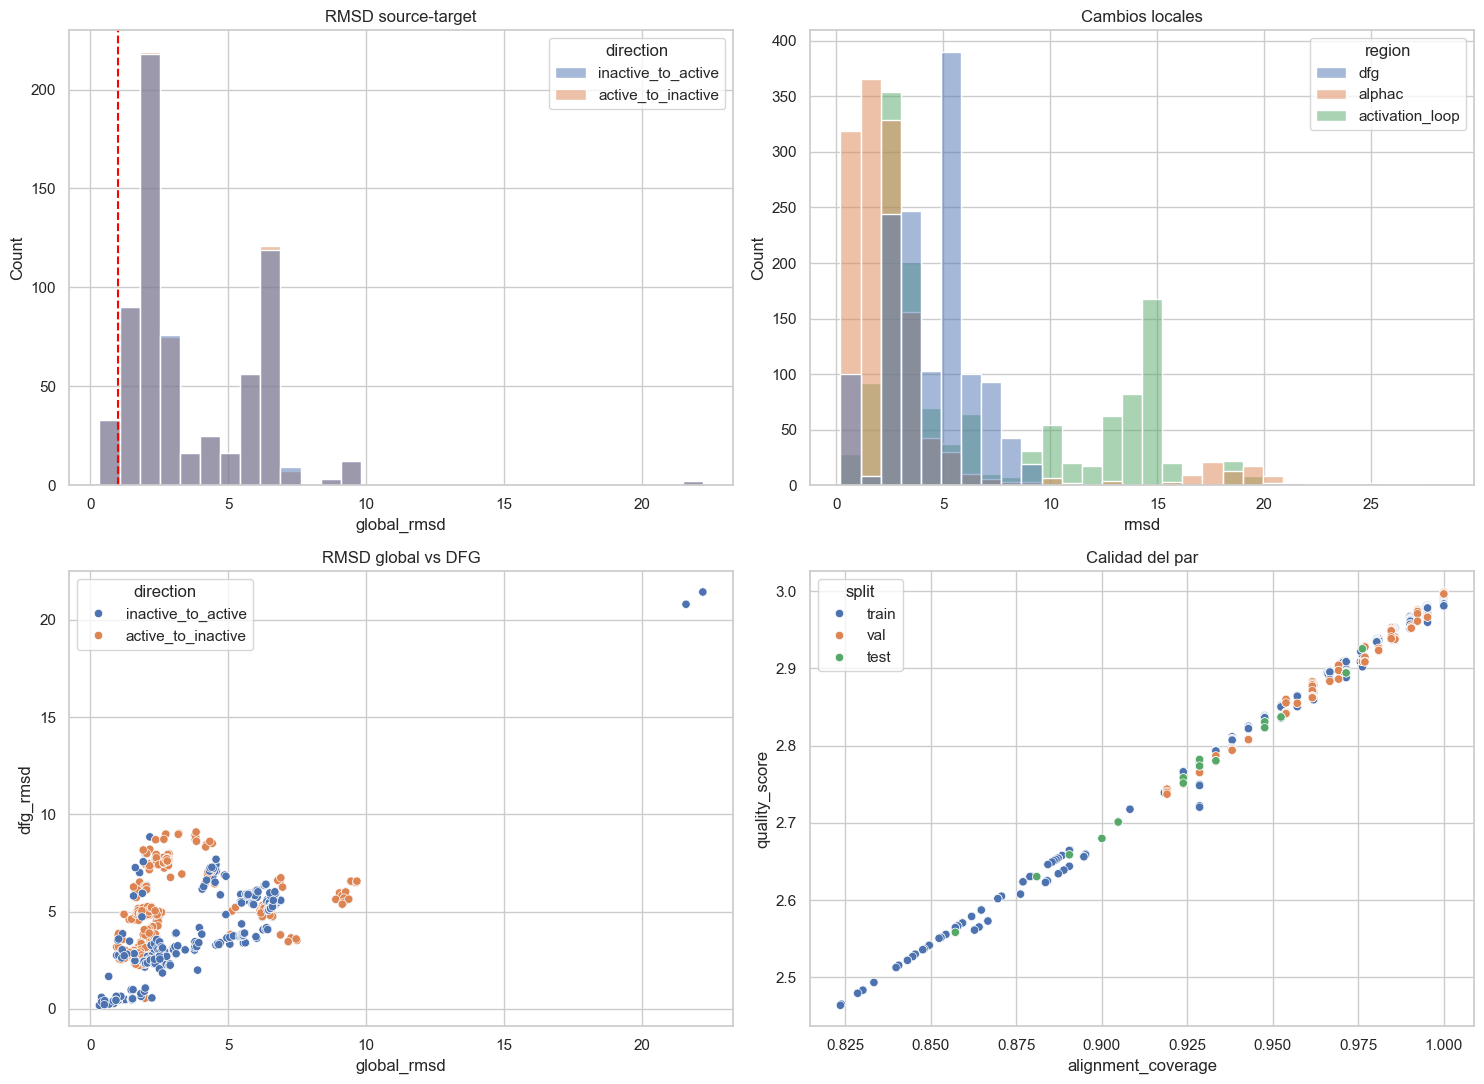

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
sns.histplot(data=pair_table, x="global_rmsd", hue="direction", bins=30, ax=axes[0, 0])
axes[0, 0].axvline(1.0, color="red", ls="--"); axes[0, 0].set_title("RMSD source-target")
sns.histplot(data=regional_changes, x="rmsd", hue="region", bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Cambios locales")
sns.scatterplot(data=pair_table, x="global_rmsd", y="dfg_rmsd", hue="direction", ax=axes[1, 0])
axes[1, 0].set_title("RMSD global vs DFG")
sns.scatterplot(data=pair_table, x="alignment_coverage", y="quality_score", hue="split", ax=axes[1, 1])
axes[1, 1].set_title("Calidad del par")
fig.tight_layout()
fig.savefig(FIGURES / "pair_distributions.png", dpi=200, bbox_inches="tight")
plt.show()


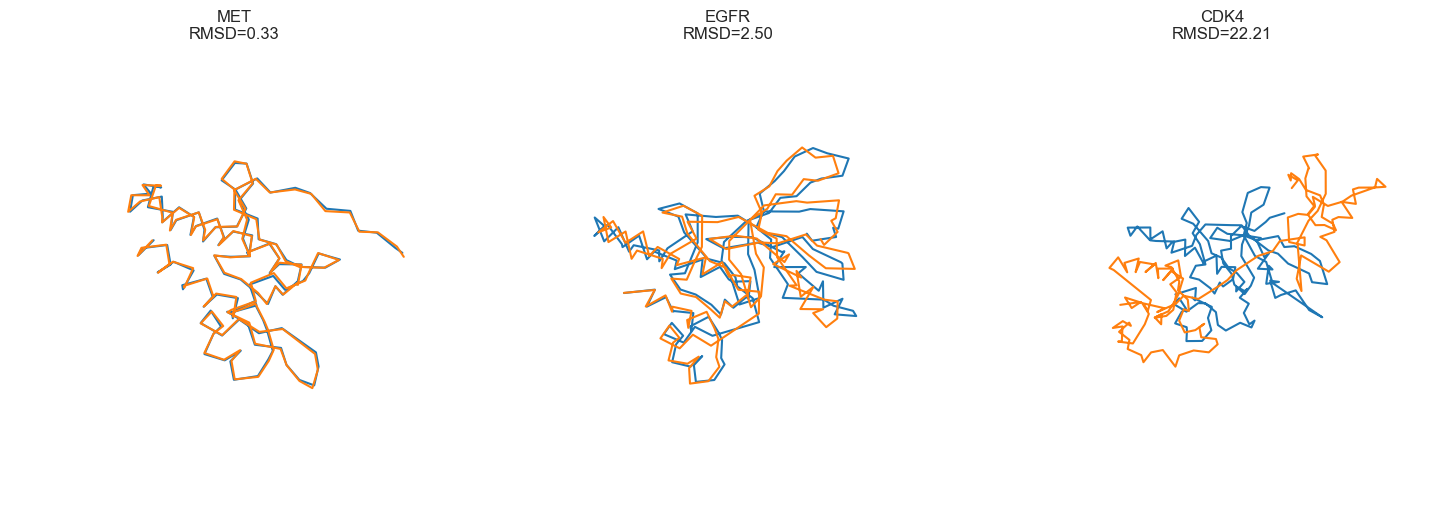

In [14]:
def show_pair_examples(rows, filename):
    fig = plt.figure(figsize=(15, 5))
    for panel, row in enumerate(rows.itertuples(), 1):
        source = domain_lookup[row.source_pdb]
        target = domain_lookup[row.weak_target_pdb]
        prepared = exp.prepare_pair(source, target, CONFIG)
        valid = prepared["mask"]
        scale = float(prepared["scale"])
        x0 = prepared["x0"][valid].numpy() * scale
        x1 = prepared["x1"][valid].numpy() * scale
        ax = fig.add_subplot(1, len(rows), panel, projection="3d")
        ax.plot(*x0.T, color="tab:blue", label="source")
        ax.plot(*x1.T, color="tab:orange", label="target")
        ax.set_title(f"{row.kinase}\nRMSD={row.global_rmsd:.2f}")
        ax.set_axis_off(); equal_3d(ax, np.vstack([x0, x1]))
    fig.tight_layout(); fig.savefig(FIGURES / filename, dpi=200, bbox_inches="tight"); plt.show()

examples = pd.concat([
    pair_table.nsmallest(1, "global_rmsd"),
    pair_table.iloc[(pair_table.global_rmsd - pair_table.global_rmsd.median()).abs().argsort()[:1]],
    pair_table.nlargest(1, "global_rmsd"),
])
show_pair_examples(examples, "pair_examples_good_ambiguous_bad.png")


## 7. Baselines corregidos

El vecino real y el promedio se alinean para cada source y excluyen el weak target. El delta medio
por quinasa se estima solo con train.


In [15]:
mean_delta_by_kinase = exp.mean_deltas(datasets["train"])
baseline_rows = []
for raw_batch in loaders["val"]:
    batch = exp.move_batch(raw_batch, DEVICE)
    frames = exp.baselines(batch)
    frames.update(exp.independent_target_baselines(batch, domain_lookup, domains["val"], CONFIG))
    exp.add_mean_delta_baseline(frames, batch, mean_delta_by_kinase)
    for method, coords in frames.items():
        frame = exp.evaluate(coords, batch, classifier)
        frame["method"] = method
        baseline_rows.append(frame)
baseline_validation = pd.concat(baseline_rows, ignore_index=True)
baseline_validation.to_csv(METRICS / "validation_baselines.csv", index=False)
baseline_summary = baseline_validation.groupby("method").agg(
    samples=("source_pdb", "size"),
    target_probability=("target_probability", "mean"),
    source_rmsd=("rmsd_source_generated", "mean"),
    target_rmsd=("rmsd_generated_weak_target", "mean"),
    dfg_progress=("dfg_progress", "mean"),
    alphac_progress=("alphac_progress", "mean"),
    geometric_validity=("consecutive_ca_valid_fraction", "mean"),
).reset_index()
display(baseline_summary)


,method,samples,target_probability,source_rmsd,target_rmsd,dfg_progress,alphac_progress,geometric_validity
0,aligned_batch_target_mean,384,0.495191,4.352413,1.795922,-0.004988,0.002232,0.890272
1,aligned_target_state_mean,384,0.459765,6.612484,4.848207,-0.040128,-0.100251,0.280994
2,copy_source,384,0.373493,0.000000,4.807820,0.000000,0.000000,0.998780
3,independent_nearest_real_target,384,0.589516,5.914123,3.919935,-0.000188,0.004916,0.909062
4,mean_delta_by_kinase,384,0.373493,0.000000,4.807820,0.000000,0.000000,0.998780
5,random_noise,384,0.453845,0.594644,4.863529,-0.006754,-0.005834,0.792718
6,simple_interpolation,384,0.482810,1.201955,3.605865,-0.006586,-0.006428,0.922200
7,weak_target_oracle,384,0.616197,4.807820,0.000000,0.041668,0.060818,0.998758


## 8. Modelo local Flow Matching + CFG

El modelo aprende una velocidad en espacio de deltas. La movilidad del core conservado se amortigua
y las regiones funcionales reciben capacidad completa.


In [16]:
model = exp.LocalDeltaFlow(CONFIG, len(KINASE_VOCAB)).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG.epochs)
print(f"Parámetros: {sum(parameter.numel() for parameter in model.parameters()):,}")
sample_batch = exp.move_batch(next(iter(loaders["train"])), DEVICE)
with torch.no_grad():
    prediction = model(
        torch.zeros_like(sample_batch["x0"]),
        torch.rand(len(sample_batch["x0"]), device=DEVICE),
        sample_batch,
    )
assert prediction.shape == sample_batch["x0"].shape
print("Forward válido:", prediction.shape)


/Users/josefinadehan/miniforge3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Parámetros: 1,300,611
Forward válido: torch.Size([8, 144, 3])


## 9. Entrenamiento y checkpoints

Se guardan el mejor checkpoint por validation loss y el mejor por score local/plausibilidad.


In [17]:
def numeric_mean_dict(rows):
    """Promedia métricas numéricas sin intentar agregar metadata textual."""
    frame = pd.DataFrame(rows).apply(pd.to_numeric, errors="coerce")
    return frame.mean(numeric_only=True).dropna().to_dict()


def validation_metrics(model, loader, generate):
    losses, parts, generated_rows = [], [], []
    model.eval()
    with torch.no_grad():
        for raw_batch in loader:
            batch = exp.move_batch(raw_batch, DEVICE)
            loss, components = exp.loss_components(model, batch, CONFIG, training=False)
            losses.append(float(loss)); parts.append(components)
            if generate:
                generated = exp.integrate(
                    model, batch, CONFIG.guidance_scale, CONFIG.integration_steps
                )[1.0].to(DEVICE)
                generated_rows.append(exp.evaluate(generated, batch, classifier))
    result = {"validation_loss": np.mean(losses)}
    result.update({f"validation_{k}": v for k, v in numeric_mean_dict(parts).items()})
    if generated_rows:
        frame = pd.concat(generated_rows, ignore_index=True)
        result.update({
            "validation_rmsd_source_generated": frame.rmsd_source_generated.mean(),
            "validation_rmsd_generated_target": frame.rmsd_generated_weak_target.mean(),
            "validation_dfg_progress": frame.dfg_progress.mean(),
            "validation_alphac_progress": frame.alphac_progress.mean(),
            "validation_activation_loop_progress": frame.activation_loop_progress.mean(),
            "validation_plausibility": (
                frame.consecutive_ca_valid_fraction.mean()
                + frame.global_conservation.mean()
                + max(0, frame.feature_progress_to_target.mean())
            ) / 3,
        })
    return result

history = []
best_loss = best_local = float("inf")
stale = 0
for epoch in tqdm(range(1, CONFIG.epochs + 1), desc="Entrenamiento"):
    model.train(); train_rows = []
    for raw_batch in loaders["train"]:
        batch = exp.move_batch(raw_batch, DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss, components = exp.loss_components(model, batch, CONFIG, training=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
        optimizer.step()
        train_rows.append({"train_loss": float(loss.detach()), **{f"train_{k}": v for k, v in components.items()}})
    generate = epoch == 1 or epoch % CONFIG.validation_every == 0
    validation = validation_metrics(model, loaders["val"], generate)
    row = {
        "epoch": epoch, **numeric_mean_dict(train_rows), **validation,
        "learning_rate": optimizer.param_groups[0]["lr"],
    }
    history.append(row)
    local_score = (
        validation.get("validation_rmsd_generated_target", 10)
        - validation.get("validation_dfg_progress", 0)
        - validation.get("validation_alphac_progress", 0)
        - validation.get("validation_activation_loop_progress", 0)
        - validation.get("validation_plausibility", 0)
    )
    checkpoint = {
        "model_state": model.state_dict(), "optimizer_state": optimizer.state_dict(),
        "epoch": epoch, "validation_loss": validation["validation_loss"],
        "local_score": local_score, "config": asdict(CONFIG), "kinase_vocab": KINASE_VOCAB,
    }
    torch.save(checkpoint, CHECKPOINTS / "last_model.pt")
    improved = False
    if validation["validation_loss"] < best_loss:
        best_loss = validation["validation_loss"]; improved = True
        torch.save(checkpoint, CHECKPOINTS / "best_validation_loss.pt")
    if generate and local_score < best_local:
        best_local = local_score; improved = True
        torch.save(checkpoint, CHECKPOINTS / "best_local_plausibility.pt")
    stale = 0 if improved else stale + int(generate)
    scheduler.step()
    pd.DataFrame(history).to_csv(METRICS / "training_history.csv", index=False)
    if epoch >= max(10, CONFIG.validation_every) and stale >= CONFIG.patience:
        print("Early stopping:", epoch)
        break

history_df = pd.DataFrame(history)
best = torch.load(CHECKPOINTS / "best_local_plausibility.pt", map_location=DEVICE, weights_only=False)
model.load_state_dict(best["model_state"]); model.eval()
print("Checkpoint seleccionado:", best["epoch"], "local_score:", best["local_score"])


Entrenamiento:  91%|█████████ | 454/500 [14:25:44<1:27:43, 114.41s/it] 

Early stopping: 455
Checkpoint seleccionado: 305 local_score: 3.4098739873734303


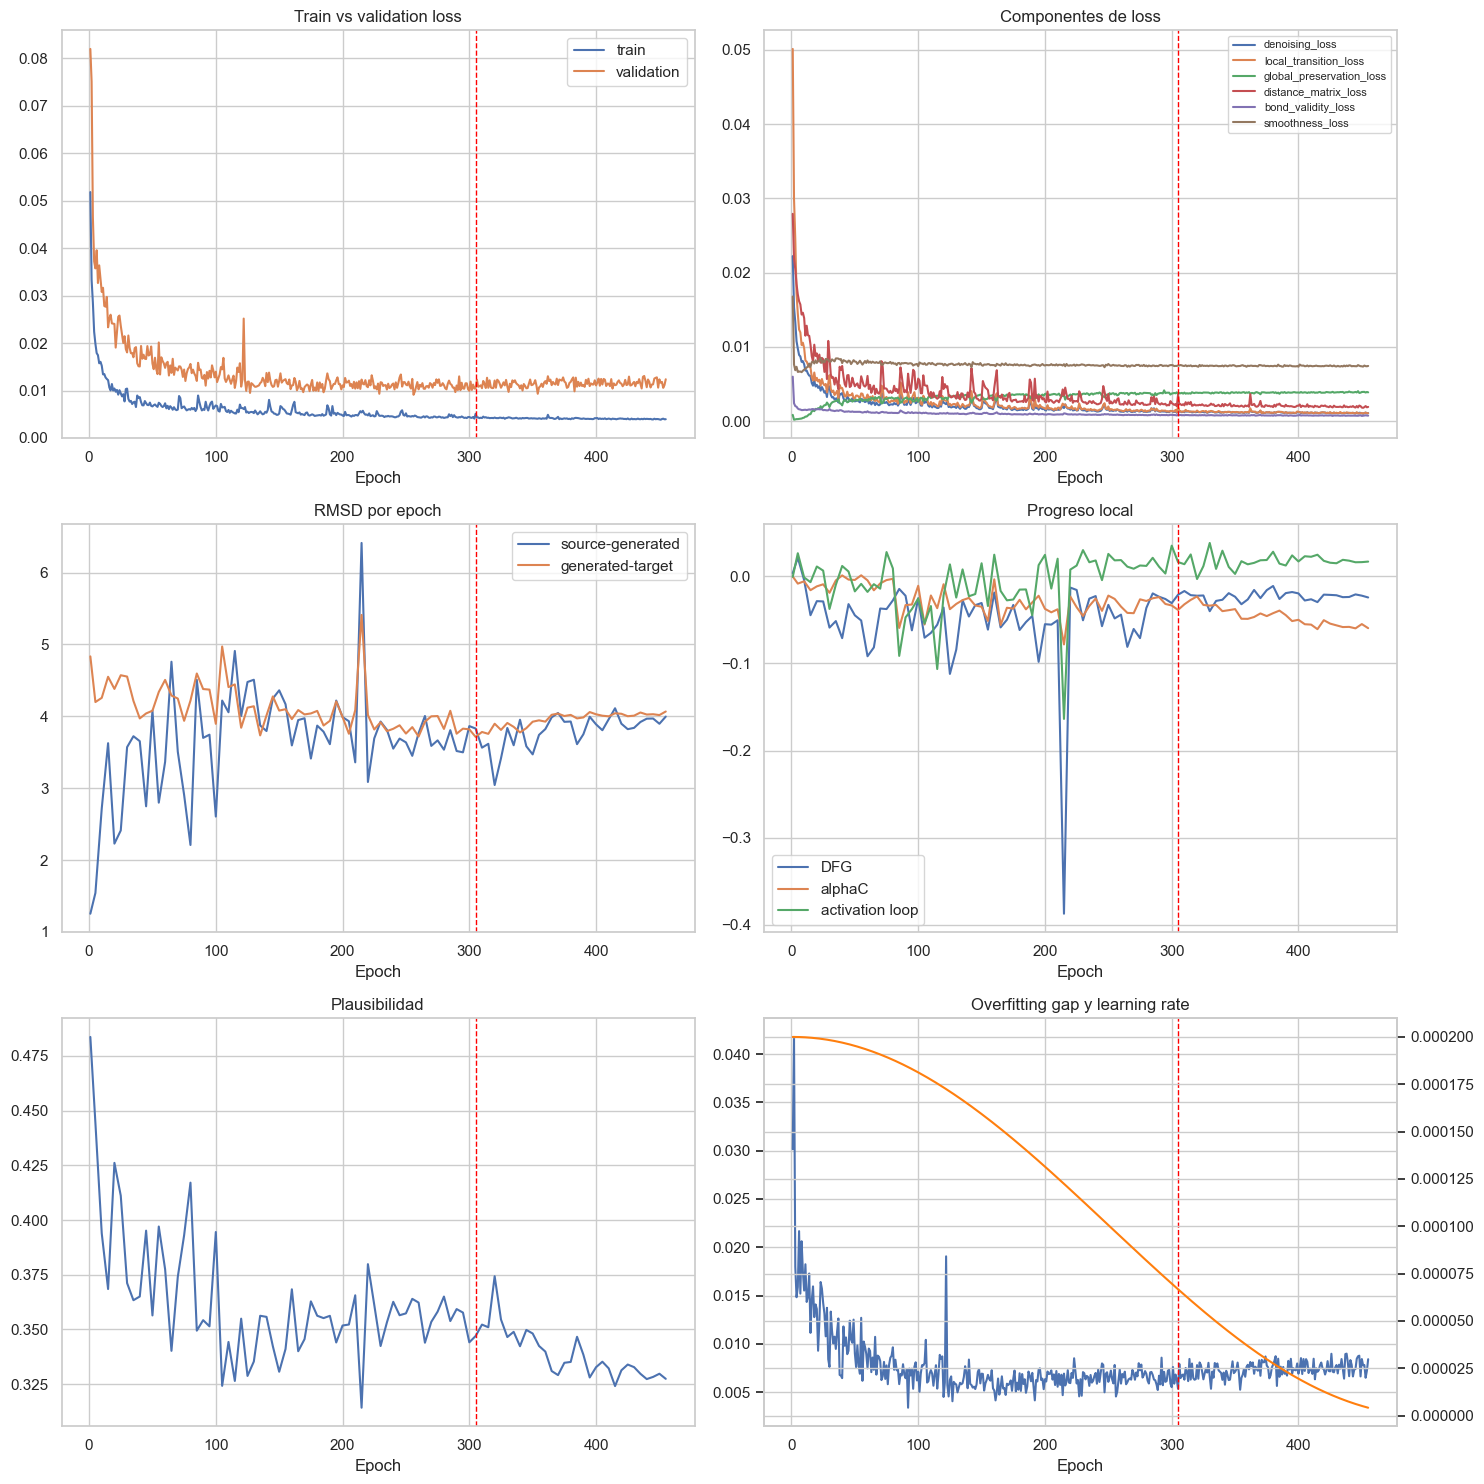

In [18]:
observed = history_df.dropna(subset=["validation_plausibility"])
best_epoch = int(best["epoch"])
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes[0, 0].plot(history_df.epoch, history_df.train_loss, label="train")
axes[0, 0].plot(history_df.epoch, history_df.validation_loss, label="validation")
axes[0, 0].set_title("Train vs validation loss"); axes[0, 0].legend()
component_columns = [
    "train_denoising_loss", "train_local_transition_loss",
    "train_global_preservation_loss", "train_distance_matrix_loss",
    "train_bond_validity_loss", "train_smoothness_loss",
]
for column in component_columns:
    axes[0, 1].plot(history_df.epoch, history_df[column], label=column.replace("train_", ""))
axes[0, 1].set_title("Componentes de loss"); axes[0, 1].legend(fontsize=8)
axes[1, 0].plot(observed.epoch, observed.validation_rmsd_source_generated, label="source-generated")
axes[1, 0].plot(observed.epoch, observed.validation_rmsd_generated_target, label="generated-target")
axes[1, 0].set_title("RMSD por epoch"); axes[1, 0].legend()
axes[1, 1].plot(observed.epoch, observed.validation_dfg_progress, label="DFG")
axes[1, 1].plot(observed.epoch, observed.validation_alphac_progress, label="alphaC")
axes[1, 1].plot(observed.epoch, observed.validation_activation_loop_progress, label="activation loop")
axes[1, 1].set_title("Progreso local"); axes[1, 1].legend()
axes[2, 0].plot(observed.epoch, observed.validation_plausibility)
axes[2, 0].set_title("Plausibilidad")
axes[2, 1].plot(history_df.epoch, history_df.validation_loss - history_df.train_loss, label="overfitting gap")
ax_lr = axes[2, 1].twinx()
ax_lr.plot(history_df.epoch, history_df.learning_rate, color="tab:orange", label="learning rate")
axes[2, 1].set_title("Overfitting gap y learning rate")
for ax in axes.flat:
    ax.axvline(best_epoch, color="red", ls="--", lw=1)
    ax.set_xlabel("Epoch")
fig.tight_layout()
fig.savefig(FIGURES / "training_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()


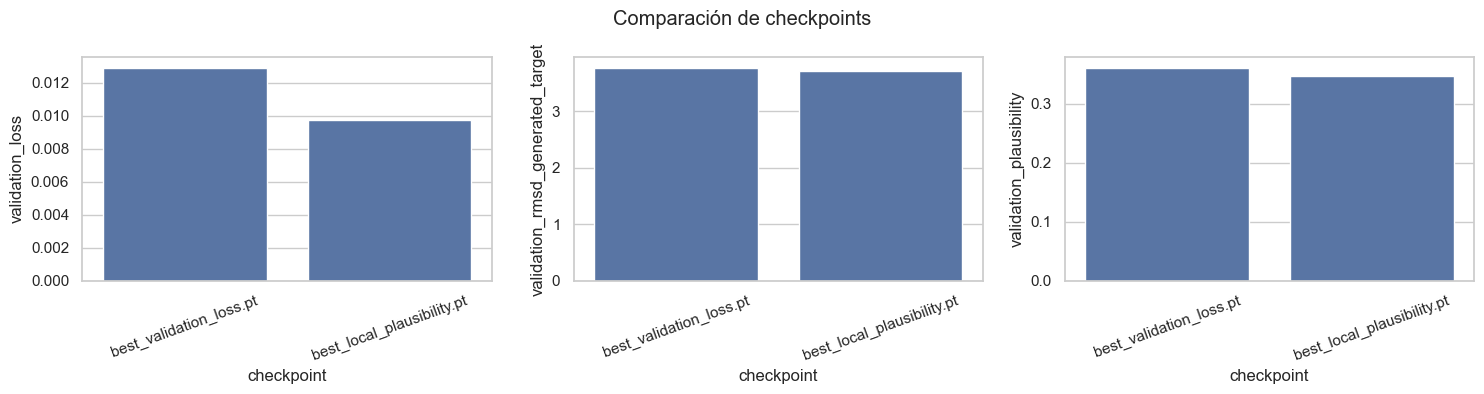

,checkpoint,epoch,validation_loss,validation_denoising_loss,validation_local_transition_loss,validation_global_preservation_loss,validation_distance_matrix_loss,validation_bond_validity_loss,validation_smoothness_loss,validation_geometry_penalty,validation_rmsd_source_generated,validation_rmsd_generated_target,validation_dfg_progress,validation_alphac_progress,validation_activation_loop_progress,validation_plausibility
0,best_validation_loss.pt,256,0.012913,0.004554,0.012504,0.002722,0.006445,0.000824,0.009521,0.000152,3.653523,3.772347,-0.041190,-0.028023,0.012830,0.361324
1,best_local_plausibility.pt,305,0.009730,0.003319,0.008600,0.002817,0.004981,0.000846,0.009396,0.000187,3.830101,3.713766,-0.021066,-0.038506,0.016443,0.347020


In [19]:
checkpoint_rows = []
for checkpoint_name in ("best_validation_loss.pt", "best_local_plausibility.pt"):
    checkpoint = torch.load(CHECKPOINTS / checkpoint_name, map_location=DEVICE, weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    metrics = validation_metrics(model, loaders["val"], generate=True)
    checkpoint_rows.append({"checkpoint": checkpoint_name, "epoch": checkpoint["epoch"], **metrics})
checkpoint_comparison = pd.DataFrame(checkpoint_rows)
checkpoint_comparison.to_csv(METRICS / "checkpoint_comparison.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=checkpoint_comparison, x="checkpoint", y="validation_loss", ax=axes[0])
sns.barplot(data=checkpoint_comparison, x="checkpoint", y="validation_rmsd_generated_target", ax=axes[1])
sns.barplot(data=checkpoint_comparison, x="checkpoint", y="validation_plausibility", ax=axes[2])
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Comparación de checkpoints")
fig.tight_layout()
fig.savefig(FIGURES / "checkpoint_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
model.load_state_dict(best["model_state"]); model.eval()
display(checkpoint_comparison)


## 10. Barrido CFG, testing y comparación de checkpoints


In [20]:
guidance_rows = []
for guidance in CONFIG.guidance_sweep:
    rows = []
    for raw_batch in loaders["val"]:
        batch = exp.move_batch(raw_batch, DEVICE)
        generated = exp.integrate(model, batch, guidance, CONFIG.integration_steps)[1.0].to(DEVICE)
        rows.append(exp.evaluate(generated, batch, classifier))
    frame = pd.concat(rows, ignore_index=True)
    guidance_rows.append({
        "guidance_scale": guidance,
        "target_probability": frame.target_probability.mean(),
        "target_rmsd": frame.rmsd_generated_weak_target.mean(),
        "dfg_progress": frame.dfg_progress.mean(),
        "alphac_progress": frame.alphac_progress.mean(),
        "geometric_validity": frame.consecutive_ca_valid_fraction.mean(),
        "global_conservation": frame.global_conservation.mean(),
    })
guidance_sweep = pd.DataFrame(guidance_rows)
guidance_sweep["selection_score"] = (
    guidance_sweep.target_rmsd
    - guidance_sweep.dfg_progress
    - guidance_sweep.alphac_progress
    - guidance_sweep.geometric_validity
    - guidance_sweep.global_conservation
)
SELECTED_GUIDANCE = float(guidance_sweep.sort_values("selection_score").iloc[0].guidance_scale)
guidance_sweep.to_csv(METRICS / "guidance_sweep.csv", index=False)
display(guidance_sweep)
print("Guidance seleccionado:", SELECTED_GUIDANCE)


,guidance_scale,target_probability,target_rmsd,dfg_progress,alphac_progress,geometric_validity,global_conservation,selection_score
0,0.0,0.386799,8.895345,-0.061546,-0.086614,0.829989,0.261255,7.952261
1,0.5,0.452915,4.956122,-0.022929,-0.106334,0.816592,0.191715,4.077079
2,1.0,0.569519,3.434514,-0.017641,-0.066682,0.857542,0.253581,2.407712
3,1.5,0.613984,3.713766,-0.021066,-0.038506,0.815003,0.226057,2.732277
4,2.0,0.631250,4.436594,-0.023087,-0.032913,0.680904,0.182830,3.628862
5,3.0,0.637079,9.121084,-0.022742,-0.073184,0.424445,0.099423,8.693142


Guidance seleccionado: 1.0


In [21]:
test_rows = []
trajectory_by_source = {}
for raw_batch in tqdm(loaders["test"], desc="Test"):
    batch = exp.move_batch(raw_batch, DEVICE)
    trajectory = exp.integrate(
        model, batch, SELECTED_GUIDANCE, CONFIG.integration_steps,
        save_times=(0.0, 0.2, 0.4, 0.6, 0.8, 1.0),
    )
    generated = trajectory[1.0].to(DEVICE)
    model_frame = exp.evaluate(generated, batch, classifier)
    model_frame["method"] = "local_delta_flow_cfg"
    test_rows.append(model_frame)
    frames = exp.baselines(batch)
    frames.update(exp.independent_target_baselines(batch, domain_lookup, domains["test"], CONFIG))
    exp.add_mean_delta_baseline(frames, batch, mean_delta_by_kinase)
    for method, coords in frames.items():
        frame = exp.evaluate(coords, batch, classifier)
        frame["method"] = method
        test_rows.append(frame)
    for index, source_pdb in enumerate(batch["source_pdb"]):
        trajectory_by_source[source_pdb] = {
            "raw": raw_batch, "batch_index": index,
            "trajectory": {time: value[index].numpy() for time, value in trajectory.items()},
        }

test_details = pd.concat(test_rows, ignore_index=True)
evaluation_metric_columns = [
    "target_probability", "classifier_correct", "rmsd_source_generated",
    "rmsd_generated_weak_target", "mean_residue_error_source",
    "mean_residue_error_target", "feature_progress_to_target", "dfg_progress",
    "alphac_progress", "activation_loop_progress", "consecutive_ca_valid_fraction",
    "global_conservation",
]
for column in evaluation_metric_columns:
    if column in test_details:
        test_details[column] = pd.to_numeric(test_details[column], errors="coerce")
test_details.to_csv(METRICS / "test_per_sample_and_baselines.csv", index=False)
test_summary = test_details.groupby(["method", "direction", "kinase"]).agg(
    samples=("source_pdb", "size"),
    target_probability=("target_probability", "mean"),
    rmsd_source_generated=("rmsd_source_generated", "mean"),
    rmsd_generated_target=("rmsd_generated_weak_target", "mean"),
    dfg_progress=("dfg_progress", "mean"),
    alphac_progress=("alphac_progress", "mean"),
    activation_loop_progress=("activation_loop_progress", "mean"),
    geometric_validity=("consecutive_ca_valid_fraction", "mean"),
    global_conservation=("global_conservation", "mean"),
).reset_index()
test_summary.to_csv(METRICS / "test_summary.csv", index=False)
display(test_summary)


Test: 100%|██████████| 5/5 [15:59<00:00, 191.93s/it]


,method,direction,kinase,samples,target_probability,rmsd_source_generated,rmsd_generated_target,dfg_progress,alphac_progress,activation_loop_progress,geometric_validity,global_conservation
0,aligned_batch_target_mean,active_to_inactive,PDGFRA,18,0.483622,4.264866,3.342821,-0.032216,-0.001031,-0.093227,0.832317,0.191472
1,aligned_batch_target_mean,inactive_to_active,PDGFRA,18,0.642285,3.813916,3.047621,-0.033091,-0.002593,-0.090633,0.873454,0.210139
2,aligned_target_state_mean,active_to_inactive,PDGFRA,18,0.429130,7.335474,5.355559,-0.085269,-0.163412,0.022983,0.251004,0.125296
3,aligned_target_state_mean,inactive_to_active,PDGFRA,18,0.744628,9.174120,8.913086,0.019170,-0.033524,0.031399,0.768145,0.100459
4,copy_source,active_to_inactive,PDGFRA,18,0.282219,0.000000,4.960421,0.000000,0.000000,0.000000,1.000000,1.000000
5,copy_source,inactive_to_active,PDGFRA,18,0.372601,0.000000,4.979709,0.000000,0.000000,0.000000,1.000000,1.000000
6,independent_nearest_real_target,active_to_inactive,PDGFRA,18,0.589102,7.089735,4.766964,-0.025660,-0.038371,0.091254,0.787493,0.126919
7,independent_nearest_real_target,inactive_to_active,PDGFRA,18,0.744628,9.174120,8.913086,0.019170,-0.033524,0.031399,0.768145,0.100459
8,local_delta_flow_cfg,active_to_inactive,PDGFRA,18,0.466381,3.980068,2.574261,-0.010918,-0.096015,-0.028141,0.816258,0.238125
9,local_delta_flow_cfg,inactive_to_active,PDGFRA,18,0.775443,3.091192,3.272543,-0.001587,-0.000944,0.044153,0.886013,0.274140


## 11. Evaluación por dirección, quinasa, longitud, dificultad y PIK3CA


In [24]:
model_test = test_details.query("method == 'local_delta_flow_cfg'").copy()
pair_keys = ["source_pdb", "weak_target_pdb", "direction"]
for name, method in [
    ("copy", "copy_source"),
    ("noise", "random_noise"),
    ("interpolation", "simple_interpolation"),
]:
    baseline_column = f"{name}_target_rmsd"
    reference = (
        test_details.query("method == @method")[pair_keys + ["rmsd_generated_weak_target"]]
        .groupby(pair_keys, as_index=False, observed=True)["rmsd_generated_weak_target"]
        .mean()
        .rename(columns={"rmsd_generated_weak_target": baseline_column})
    )
    model_test = model_test.merge(reference, on=pair_keys, how="left", validate="many_to_one")
    model_test[f"improvement_vs_{name}"] = (
        model_test[baseline_column] - model_test["rmsd_generated_weak_target"]
    )
model_test["source_length"] = model_test.source_pdb.map(
    domain_metadata.set_index("pdb_id").original_length
)
model_test["difficulty"] = pd.qcut(
    model_test["copy_target_rmsd"].rank(method="first"), 3,
    labels=["easy", "medium", "hard"],
).to_numpy()
model_test["pik3ca_group"] = np.where(model_test.kinase.eq("PIK3CA"), "PIK3CA", "without_PIK3CA")
model_test.to_csv(METRICS / "model_test_detailed.csv", index=False)

evaluation_axes = {}
for name, columns in {
    "by_direction": ["direction"],
    "by_kinase": ["direction", "kinase"],
    "by_initial_state": ["direction"],
    "by_difficulty": ["direction", "difficulty"],
    "with_without_pik3ca": ["pik3ca_group"],
}.items():
    frame = model_test.groupby(columns, observed=True).agg(
        samples=("source_pdb", "size"),
        improvement_vs_copy=("improvement_vs_copy", "mean"),
        improvement_vs_noise=("improvement_vs_noise", "mean"),
        improvement_vs_interpolation=("improvement_vs_interpolation", "mean"),
        source_generated_rmsd=("rmsd_source_generated", "mean"),
        generated_target_rmsd=("rmsd_generated_weak_target", "mean"),
        dfg_progress=("dfg_progress", "mean"),
        alphac_progress=("alphac_progress", "mean"),
        activation_loop_progress=("activation_loop_progress", "mean"),
        geometric_validity=("consecutive_ca_valid_fraction", "mean"),
        global_conservation=("global_conservation", "mean"),
    ).reset_index()
    frame.to_csv(METRICS / f"evaluation_{name}.csv", index=False)
    evaluation_axes[name] = frame
display(evaluation_axes["by_kinase"])


,direction,kinase,samples,improvement_vs_copy,improvement_vs_noise,improvement_vs_interpolation,source_generated_rmsd,generated_target_rmsd,dfg_progress,alphac_progress,activation_loop_progress,geometric_validity,global_conservation
0,active_to_inactive,PDGFRA,18,2.386160,2.459584,1.146055,3.980068,2.574261,-0.010918,-0.096015,-0.028141,0.816258,0.238125
1,inactive_to_active,PDGFRA,18,1.707166,1.769961,0.462239,3.091192,3.272543,-0.001587,-0.000944,0.044153,0.886013,0.274140


In [25]:
final_table = evaluation_axes["by_kinase"].copy()
final_table["baseline_copy"] = final_table.generated_target_rmsd + final_table.improvement_vs_copy
final_table["model"] = final_table.generated_target_rmsd
final_table["improvement"] = final_table.improvement_vs_copy
final_table["conclusion"] = np.where(
    (final_table.improvement_vs_copy > 0)
    & (final_table.improvement_vs_noise > 0)
    & (final_table.improvement_vs_interpolation > 0)
    & (final_table.dfg_progress > 0)
    & (final_table.alphac_progress > 0)
    & (final_table.geometric_validity >= 0.80),
    "evidencia favorable",
    "evidencia insuficiente",
)
final_table = final_table[[
    "direction", "kinase", "samples", "baseline_copy", "model", "improvement",
    "dfg_progress", "alphac_progress", "geometric_validity", "conclusion",
]]
final_table.to_csv(METRICS / "final_test_table.csv", index=False)
display(final_table)


,direction,kinase,samples,baseline_copy,model,improvement,dfg_progress,alphac_progress,geometric_validity,conclusion
0,active_to_inactive,PDGFRA,18,4.960421,2.574261,2.386160,-0.010918,-0.096015,0.816258,evidencia insuficiente
1,inactive_to_active,PDGFRA,18,4.979709,3.272543,1.707166,-0.001587,-0.000944,0.886013,evidencia insuficiente


## 12. Cómo se hicieron las proteínas generadas

Se seleccionan cinco casos: mejores/peores de ambas direcciones y PIK3CA o un caso excluido.
Cada figura muestra dominio usado, regiones, ruido, trayectoria, resultado y referencias reales.


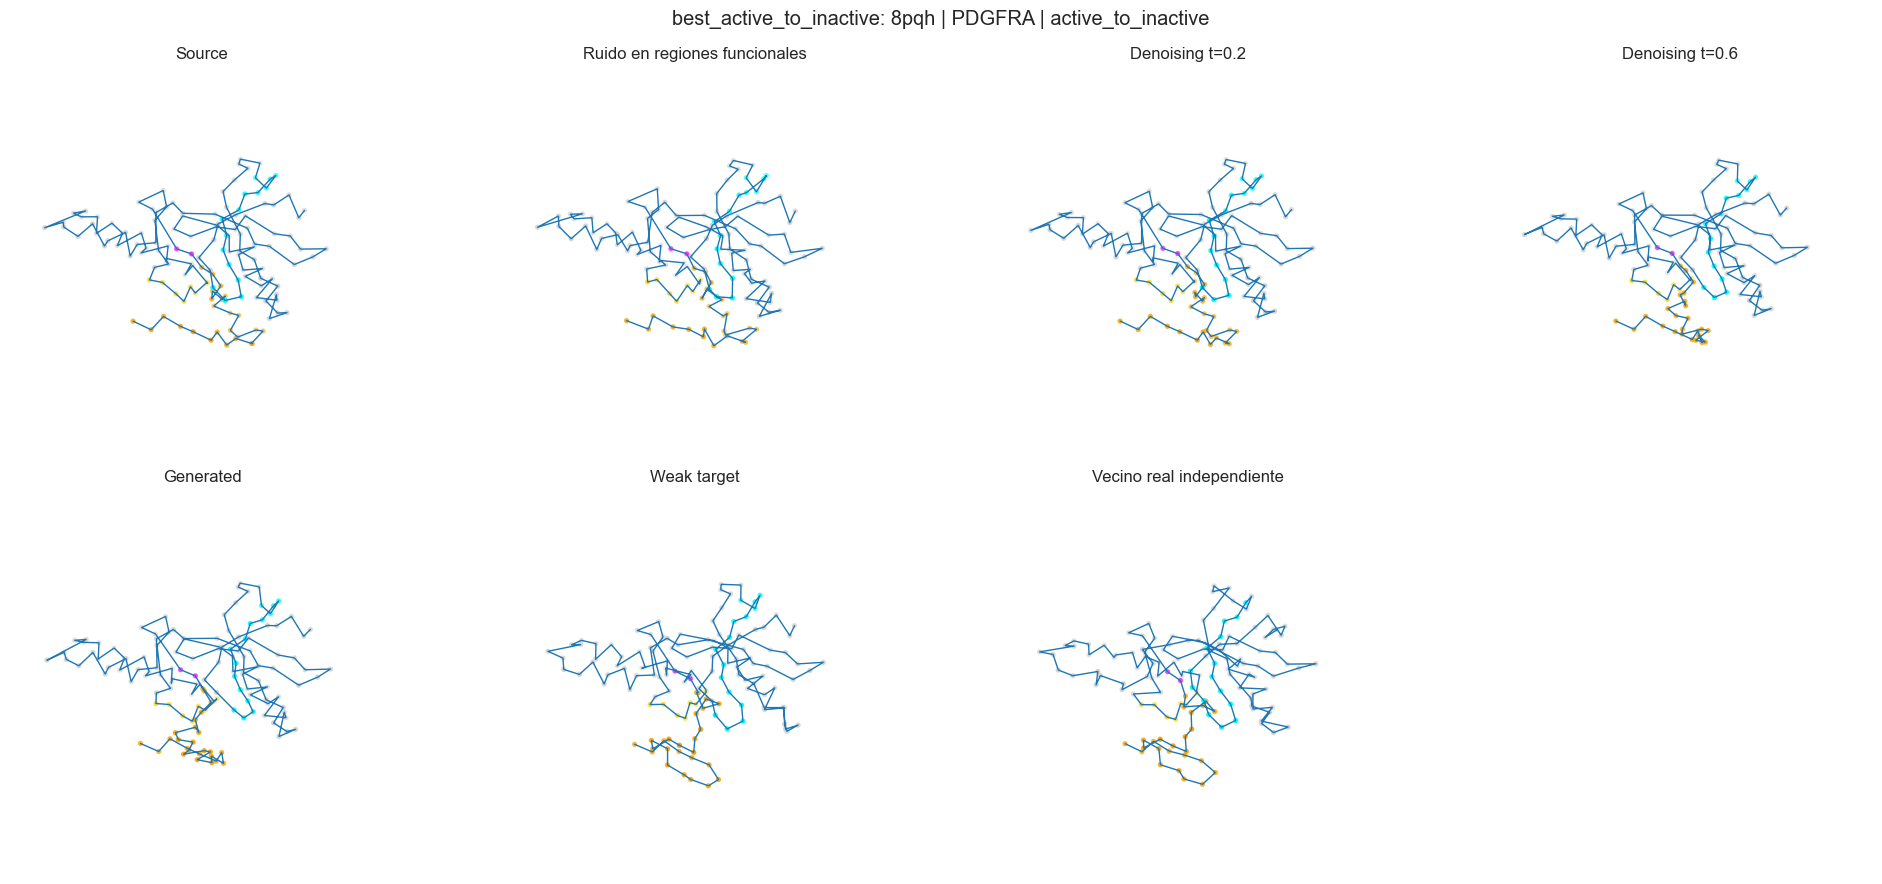

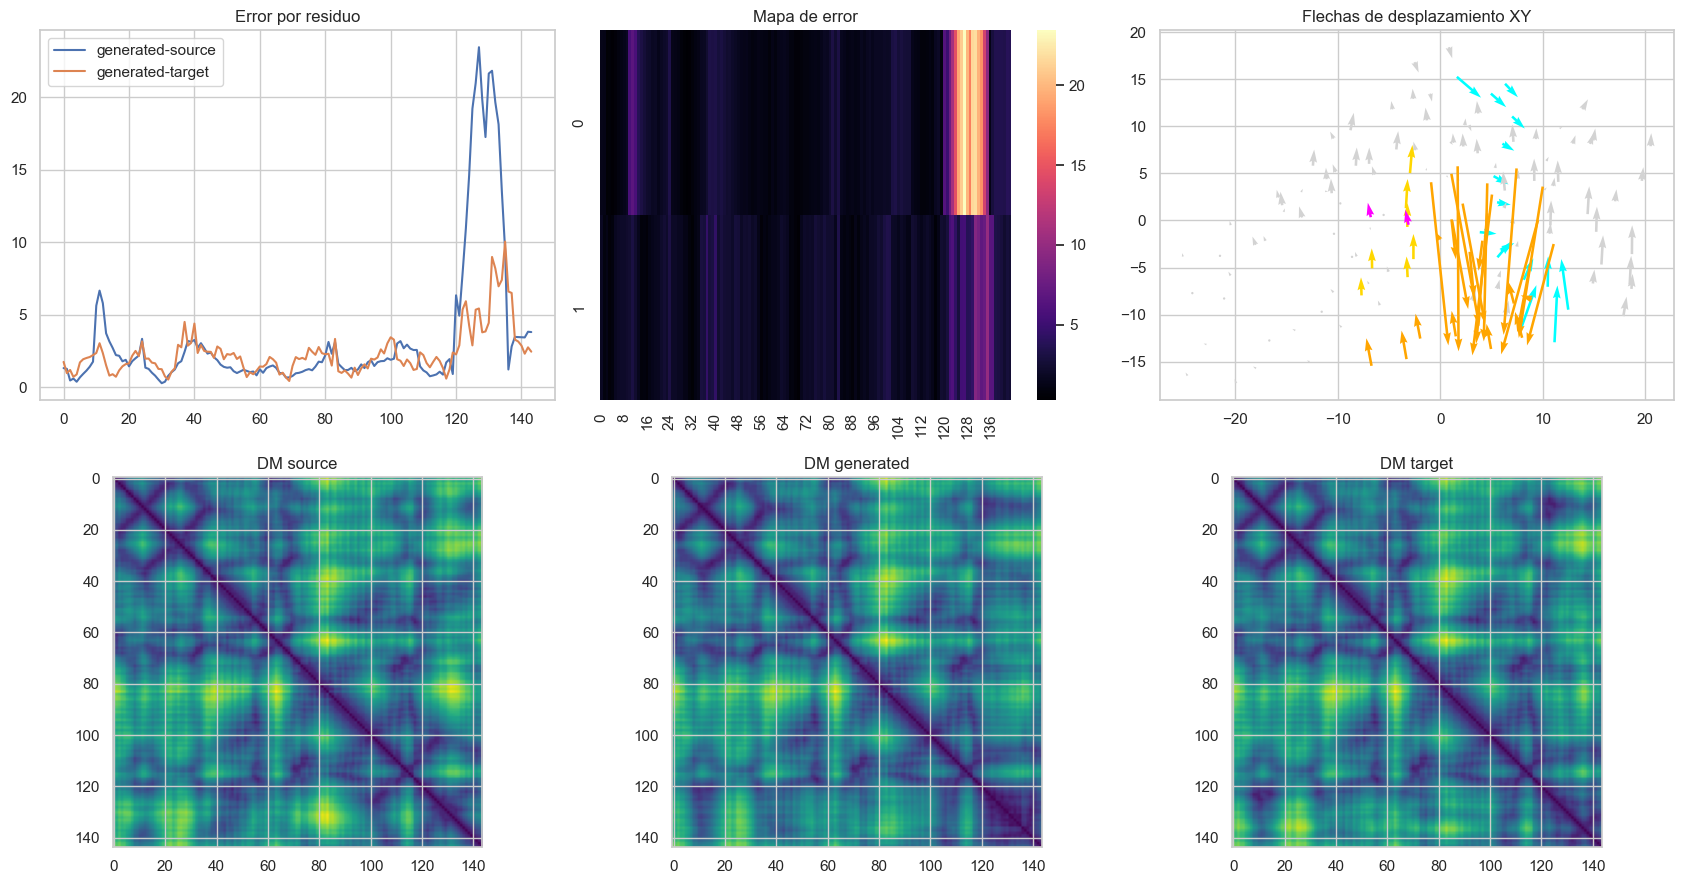

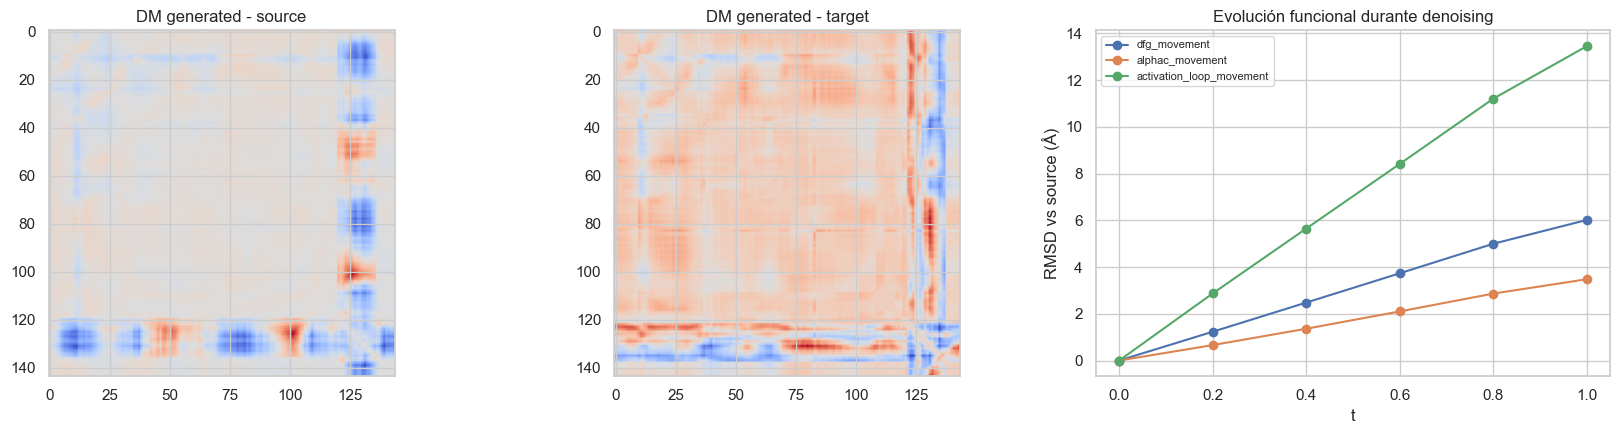

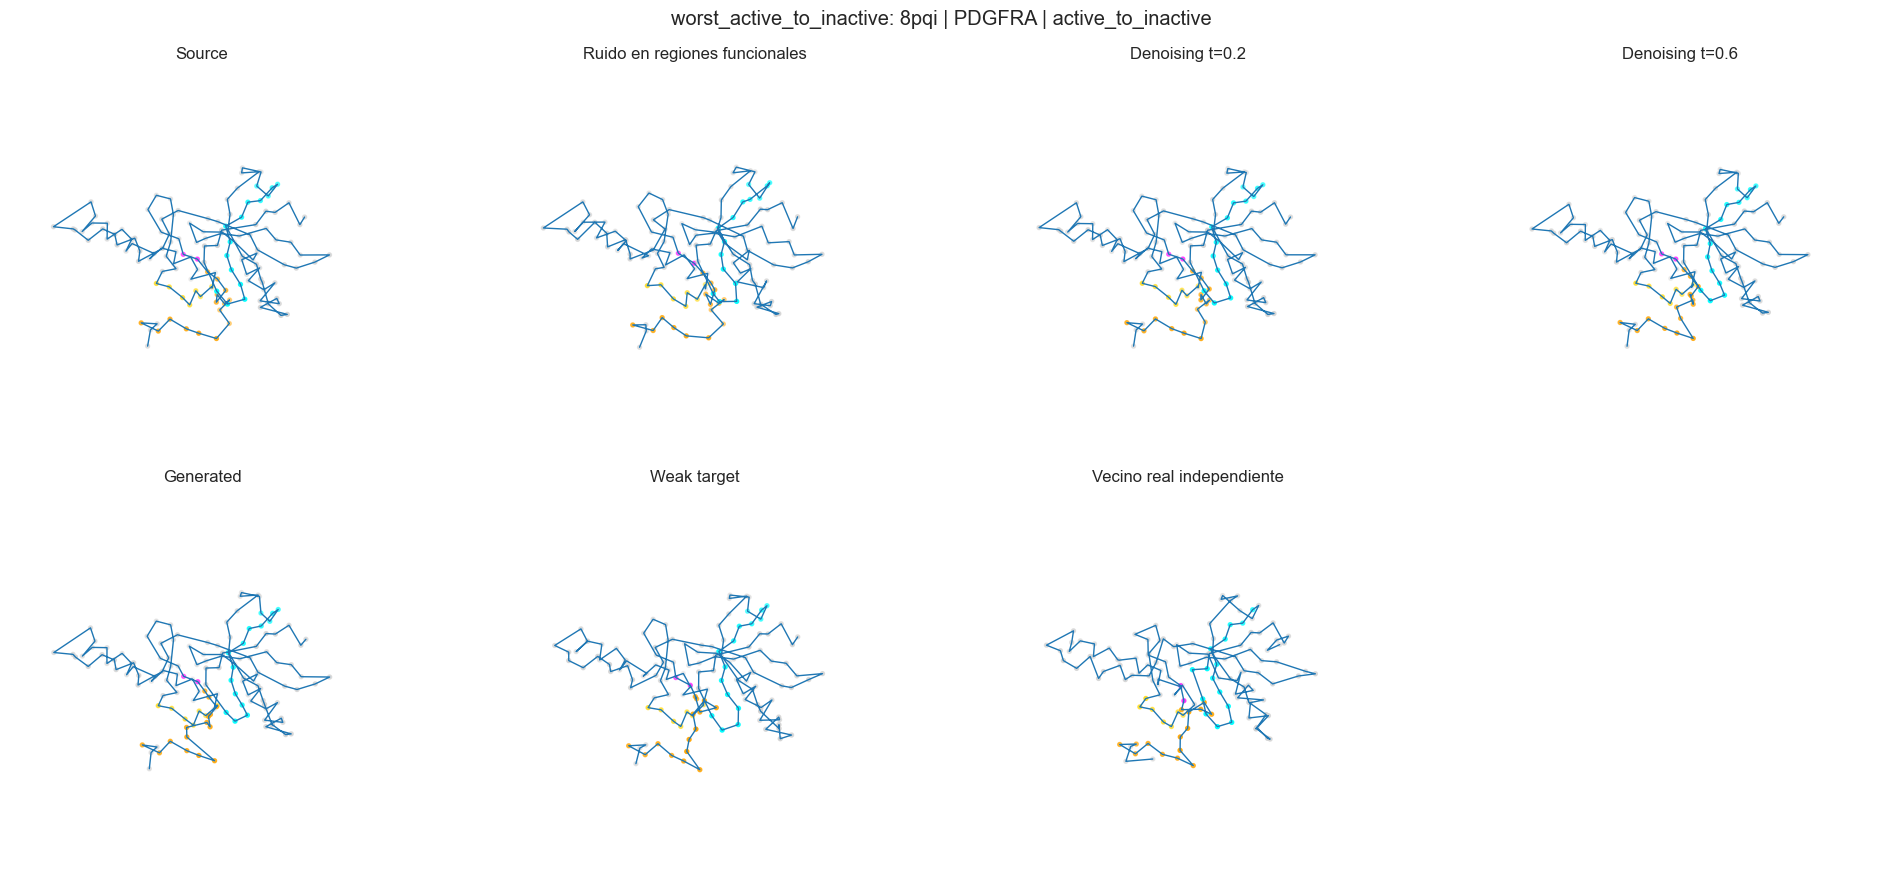

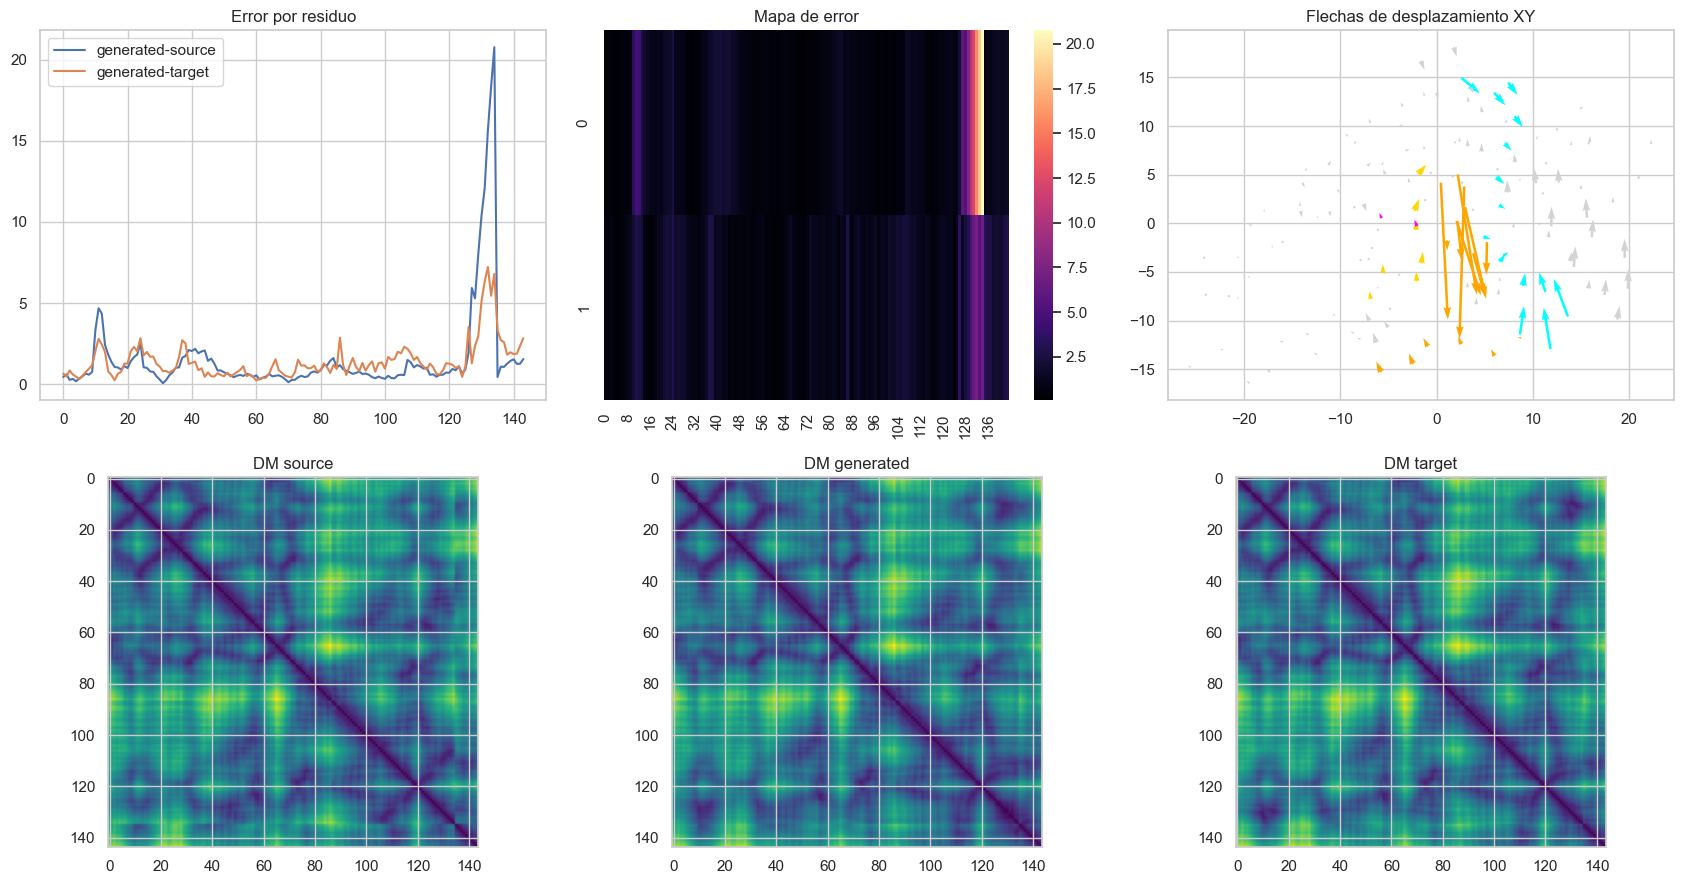

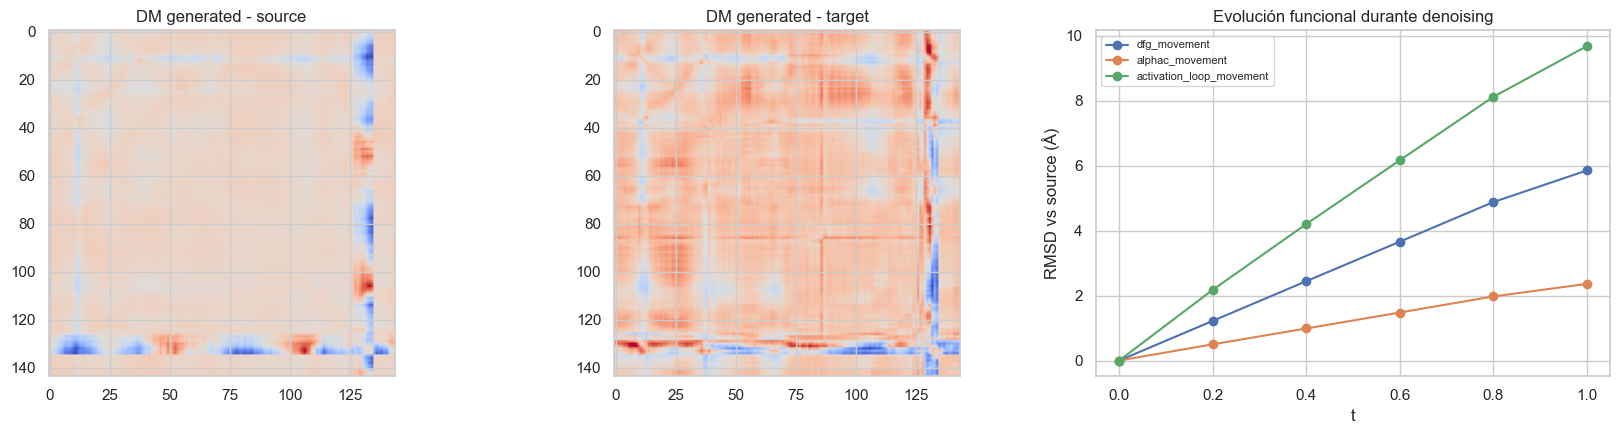

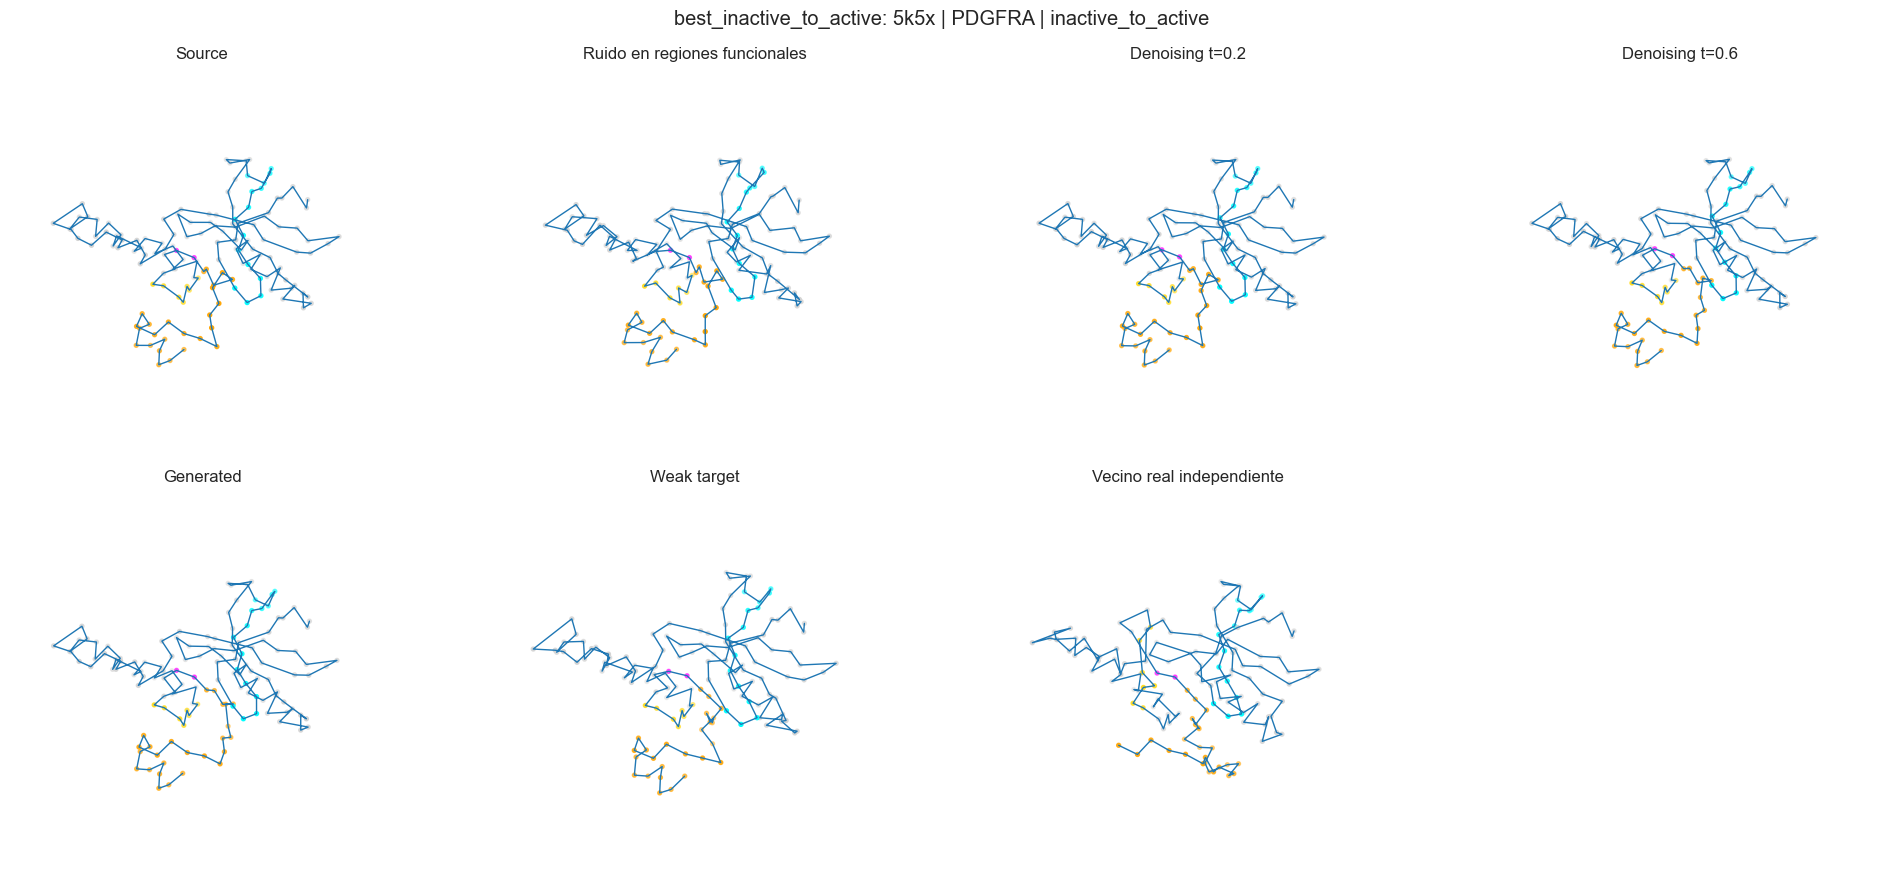

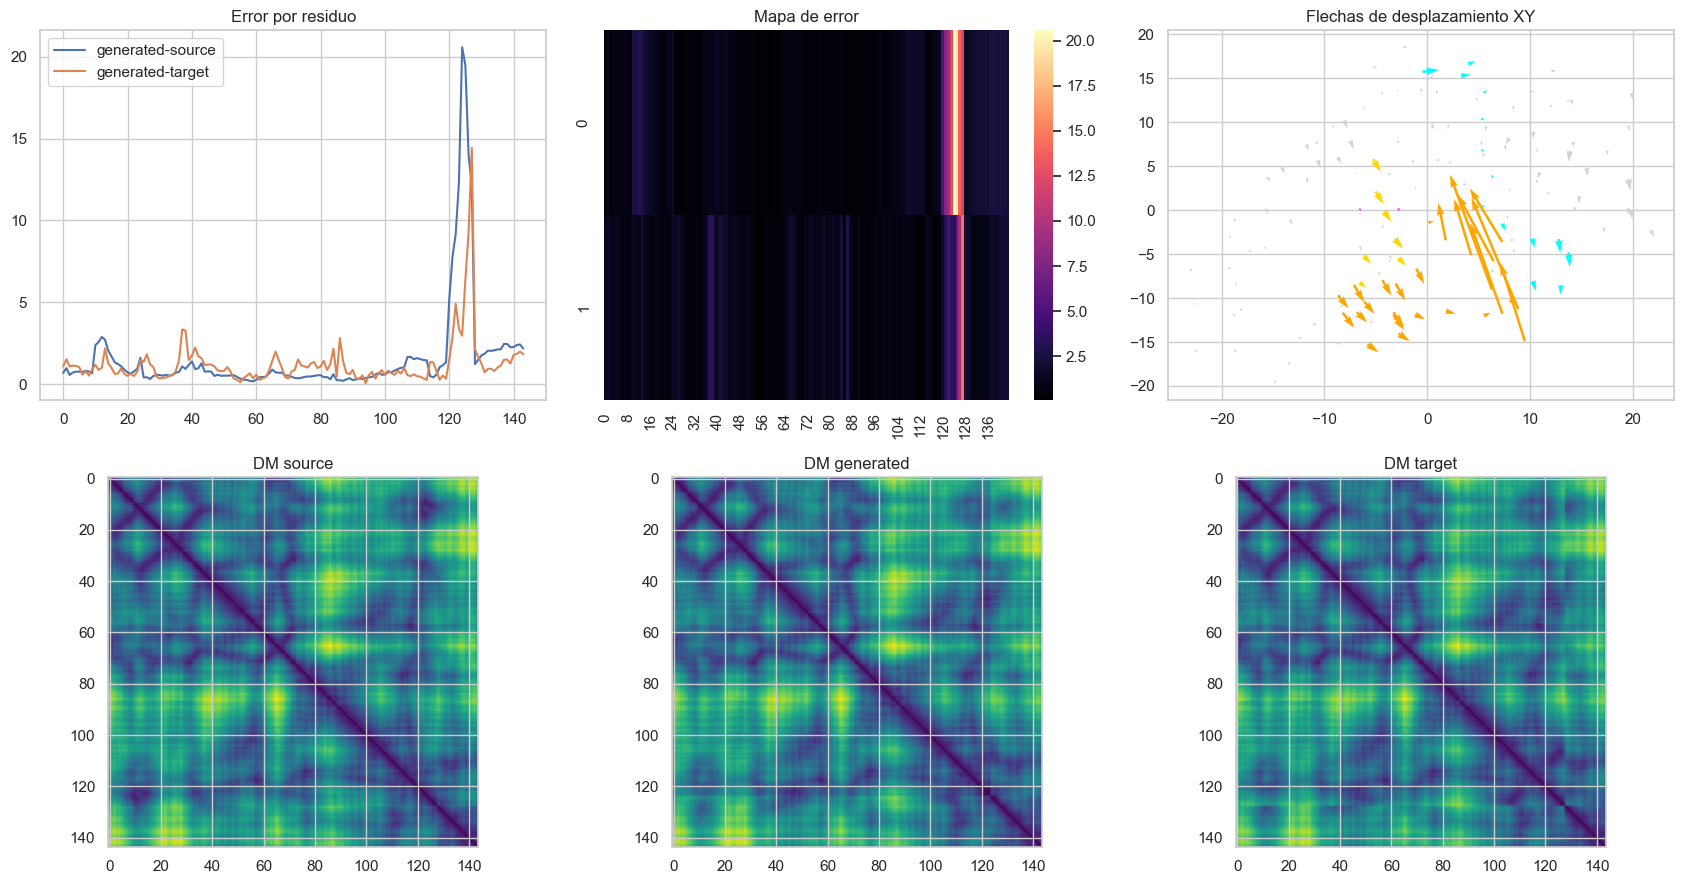

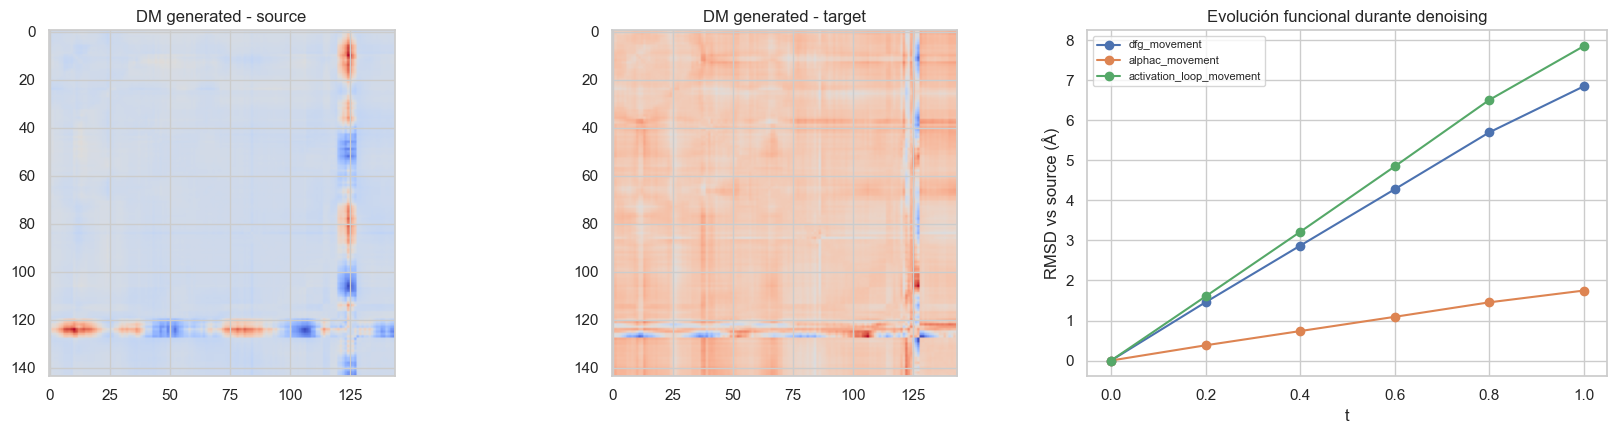

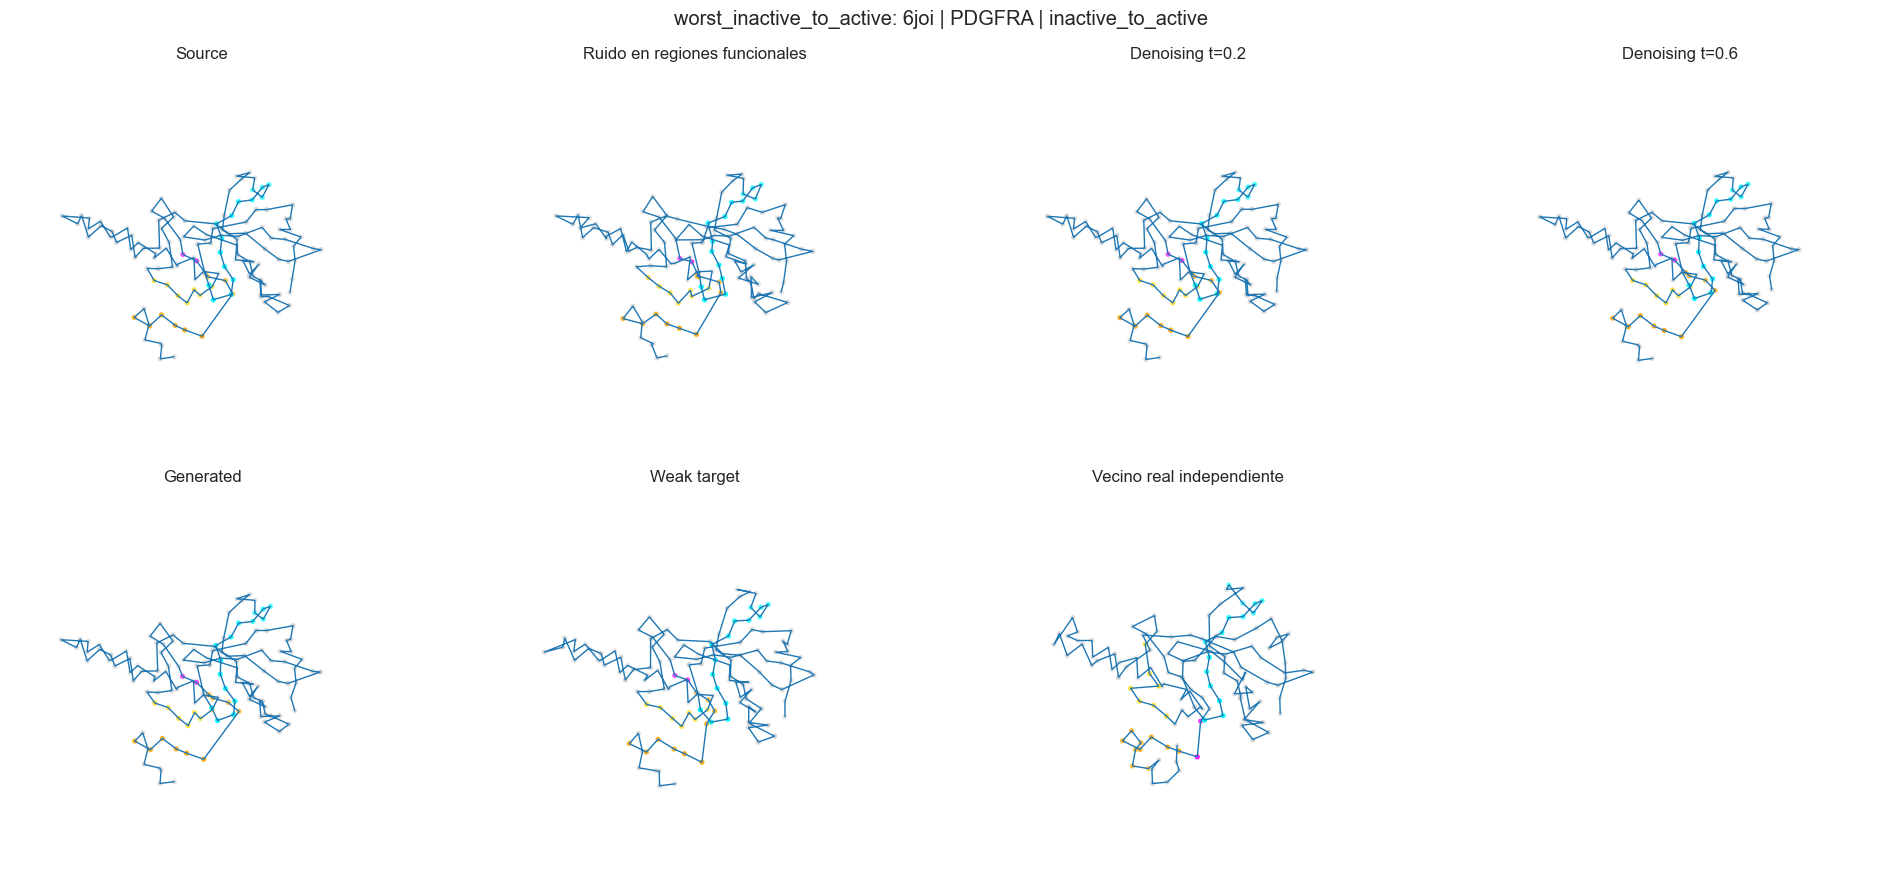

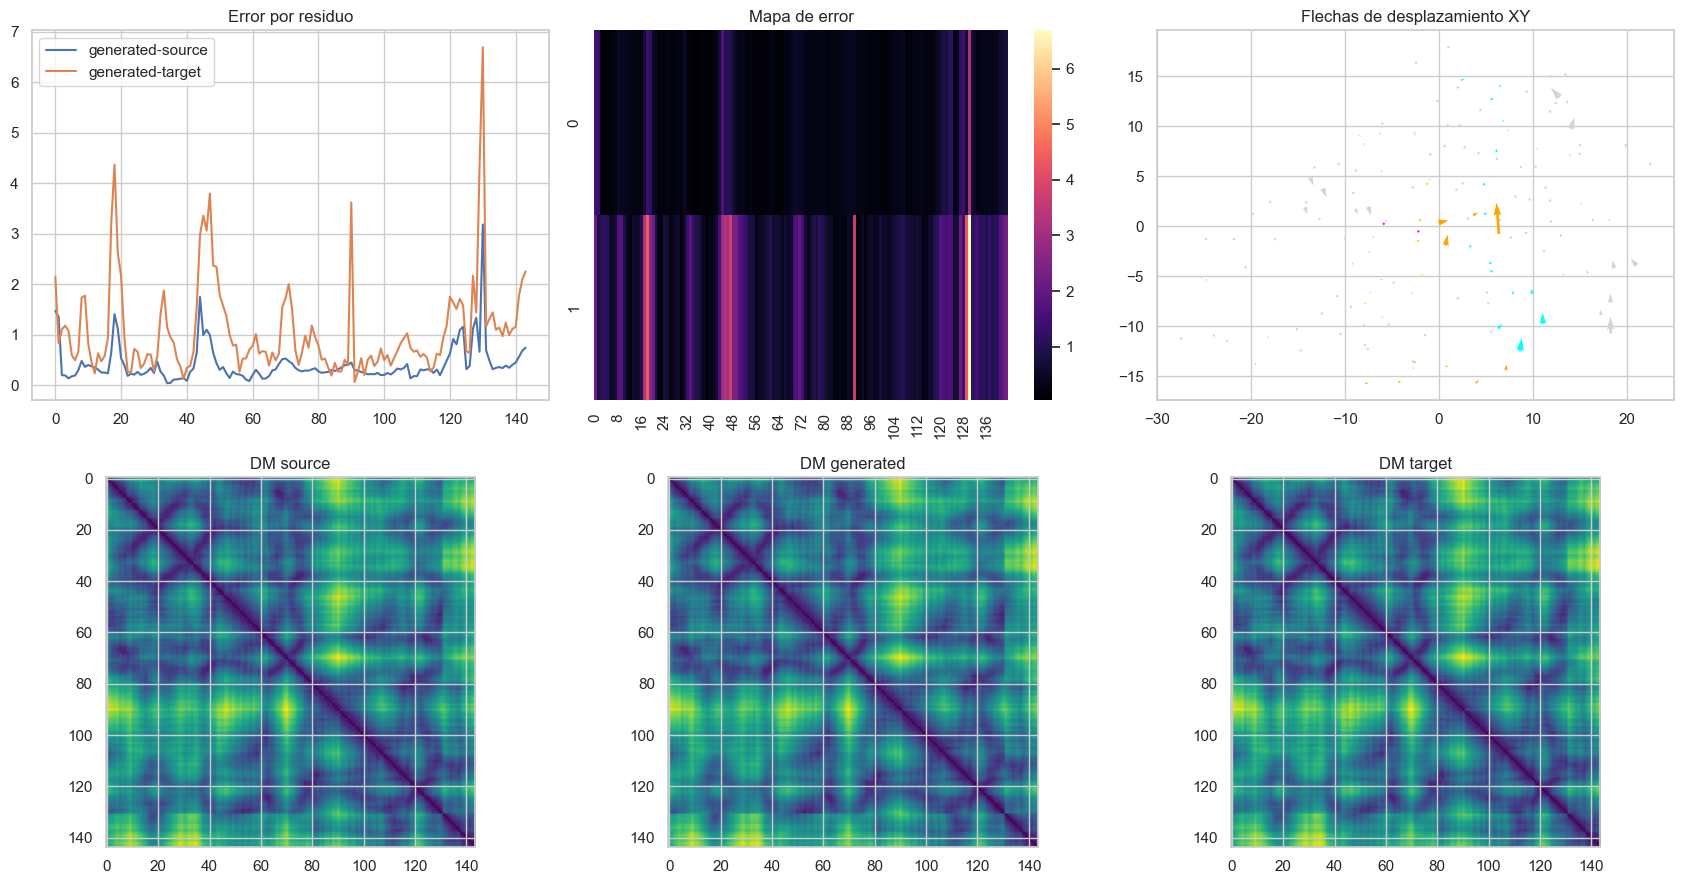

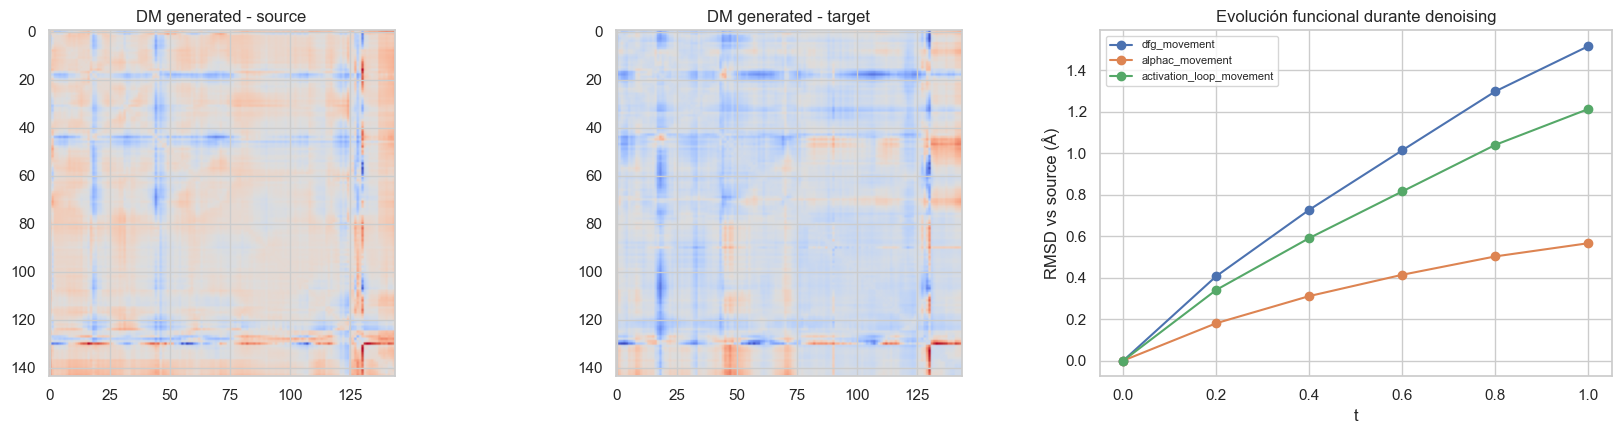

### Caso PIK3CA diagnosticado
PDB `2rd0`, longitud original `997`, aceptado=`False`, motivo=`missing_motifs:hrd`. No se genera una estructura cuando la correspondencia funcional no es fiable.

In [26]:
def region_colors(item, valid):
    colors = np.array(["lightgray"] * int(valid.sum()), dtype=object)
    palette = {"dfg": "magenta", "alphac": "cyan", "hrd": "gold", "activation_loop": "orange"}
    for region, color in palette.items():
        colors[item[f"{region}_mask"][valid].numpy()] = color
    return colors

def visualize_generation_case(source_pdb, rank_name):
    payload = trajectory_by_source[source_pdb]
    raw_batch, index = payload["raw"], payload["batch_index"]
    item = {key: value[index] if torch.is_tensor(value) else value[index] for key, value in raw_batch.items()}
    valid = item["mask"].bool()
    scale = float(item["scale"])
    source = item["x0"][valid].numpy() * scale
    target = item["x1"][valid].numpy() * scale
    generated = payload["trajectory"][1.0][valid.numpy()] * scale
    noisy = source + np.random.default_rng(CONFIG.seed).normal(0, CONFIG.noise_std * scale, source.shape)
    colors = region_colors(item, valid)
    single_raw = {
        key: value[index:index+1] if torch.is_tensor(value) else [value[index]]
        for key, value in raw_batch.items()
    }
    single_batch = exp.move_batch(single_raw, DEVICE)
    independent = exp.independent_target_baselines(
        single_batch, domain_lookup, domains["test"], CONFIG
    )["independent_nearest_real_target"][0].detach().cpu()
    real_neighbor = independent[valid].numpy() * scale

    times = sorted(payload["trajectory"])
    fig = plt.figure(figsize=(20, 9))
    panels = [
        (source, "Source"), (noisy, "Ruido en regiones funcionales"),
        *[(payload["trajectory"][time][valid.numpy()] * scale, f"Denoising t={time:.1f}") for time in times[1:-1:2]],
        (generated, "Generated"), (target, "Weak target"),
        (real_neighbor, "Vecino real independiente"),
    ]
    for panel, (xyz, title) in enumerate(panels[:8], 1):
        ax = fig.add_subplot(2, 4, panel, projection="3d")
        ax.plot(*xyz.T, color="tab:blue", lw=1)
        ax.scatter(*xyz.T, c=colors, s=8)
        ax.set_title(title); ax.set_axis_off(); equal_3d(ax, xyz)
    fig.suptitle(f"{rank_name}: {source_pdb} | {item['kinase']} | {item['direction']}")
    fig.tight_layout()
    fig.savefig(FIGURES / f"how_generated_{rank_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

    source_error = np.linalg.norm(generated - source, axis=-1)
    target_error = np.linalg.norm(generated - target, axis=-1)
    matrices = [np.linalg.norm(x[:, None] - x[None], axis=-1) for x in (source, generated, target)]
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))
    axes[0, 0].plot(source_error, label="generated-source")
    axes[0, 0].plot(target_error, label="generated-target")
    axes[0, 0].legend(); axes[0, 0].set_title("Error por residuo")
    sns.heatmap(np.vstack([source_error, target_error]), cmap="magma", ax=axes[0, 1])
    axes[0, 1].set_title("Mapa de error")
    displacement = generated - source
    axes[0, 2].quiver(
        source[:, 0], source[:, 1], displacement[:, 0], displacement[:, 1],
        color=colors, angles="xy", scale_units="xy", scale=1,
    )
    axes[0, 2].set_title("Flechas de desplazamiento XY")
    for ax, matrix, title in zip(axes[1], matrices, ["DM source", "DM generated", "DM target"]):
        ax.imshow(matrix, cmap="viridis"); ax.set_title(title)
    fig.tight_layout()
    fig.savefig(FIGURES / f"errors_and_matrices_{rank_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

    feature_evolution = []
    for time in times:
        xyz = payload["trajectory"][time][valid.numpy()] * scale
        row = {"time": time}
        for region in ("dfg", "alphac", "activation_loop"):
            region_mask = item[f"{region}_mask"][valid].numpy().astype(bool)
            row[f"{region}_movement"] = float(
                np.sqrt(np.mean(np.sum((xyz[region_mask] - source[region_mask]) ** 2, axis=-1)))
            ) if region_mask.any() else np.nan
        feature_evolution.append(row)
    feature_evolution = pd.DataFrame(feature_evolution)
    feature_evolution.to_csv(METRICS / f"feature_evolution_{rank_name}.csv", index=False)
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    axes[0].imshow(matrices[1] - matrices[0], cmap="coolwarm")
    axes[0].set_title("DM generated - source")
    axes[1].imshow(matrices[1] - matrices[2], cmap="coolwarm")
    axes[1].set_title("DM generated - target")
    for column in ("dfg_movement", "alphac_movement", "activation_loop_movement"):
        axes[2].plot(feature_evolution.time, feature_evolution[column], marker="o", label=column)
    axes[2].set(title="Evolución funcional durante denoising", xlabel="t", ylabel="RMSD vs source (Å)")
    axes[2].legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURES / f"distance_differences_and_feature_evolution_{rank_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

    np.savez_compressed(
        EXAMPLES / f"{rank_name}_{source_pdb}.npz",
        source=source, generated=generated, weak_target=target,
        independent_real_neighbor=real_neighbor, noisy=noisy,
        residue_error_source=source_error, residue_error_target=target_error,
        **{f"trajectory_t{time:.1f}": payload["trajectory"][time][valid.numpy()] * scale for time in times},
    )

cases = []
for direction in ("active_to_inactive", "inactive_to_active"):
    subset = model_test.query("direction == @direction")
    if len(subset):
        cases.append((subset.nlargest(1, "improvement_vs_copy").iloc[0].source_pdb, f"best_{direction}"))
        cases.append((subset.nsmallest(1, "improvement_vs_copy").iloc[0].source_pdb, f"worst_{direction}"))
for source_pdb, name in cases[:4]:
    visualize_generation_case(source_pdb, name)

if (domain_metadata.kinase == "PIK3CA").any():
    pik = domain_metadata.query("kinase == 'PIK3CA'").iloc[0]
    display(Markdown(
        f"### Caso PIK3CA diagnosticado\n"
        f"PDB `{pik.pdb_id}`, longitud original `{pik.original_length}`, "
        f"aceptado=`{pik.accepted}`, motivo=`{pik.discard_reason}`. "
        "No se genera una estructura cuando la correspondencia funcional no es fiable."
    ))


## 13. Conclusión automática

El modelo solo se declara favorable si supera copiar, ruido e interpolación, mueve DFG/alphaC hacia
el target y conserva enlaces C-alpha sobre residuos realmente consecutivos.


In [27]:
passed = final_table.conclusion.eq("evidencia favorable")
pik3ca_accepted = bool(domain_metadata.query("kinase == 'PIK3CA'").accepted.any())
lines = ["# Conclusión automática", ""]
for row in final_table.itertuples():
    lines.extend([
        f"## {row.direction} | {row.kinase}",
        f"- Mejora vs copy: {row.improvement:.3f} Å.",
        f"- Progreso DFG: {row.dfg_progress:.3f}.",
        f"- Progreso alphaC: {row.alphac_progress:.3f}.",
        f"- Validez geométrica corregida: {row.geometric_validity:.3f}.",
        f"- Diagnóstico: {row.conclusion}.", "",
    ])
if len(final_table) and passed.all():
    verdict = "El modelo supera los criterios definidos en todos los grupos evaluados."
else:
    verdict = (
        "El modelo todavía falla en al menos un criterio o grupo. "
        "No debe considerarse generador plausible de forma general."
    )
lines.extend([
    "## Geometría global",
    f"Conservación global media: {model_test.global_conservation.mean():.3f}.", "",
    "## PIK3CA",
    (
        "PIK3CA pudo incluirse con correspondencia funcional."
        if pik3ca_accepted else
        "PIK3CA debe tratarse aparte: no se detectó un dominio HRD/DFG comparable con suficiente confianza."
    ),
    "",
    "## Veredicto", verdict, "",
    "## Próximo paso recomendado",
    (
        "Mejorar el mapeo de dominios atípicos y aumentar pares balanceados por quinasa antes de "
        "incrementar capacidad o épocas."
    ),
])
conclusion = "\n".join(lines) + "\n"
(OUTPUT / "conclusion.md").write_text(conclusion, encoding="utf-8")
display(Markdown(conclusion))

print("Outputs:")
for path in sorted(OUTPUT.rglob("*")):
    if path.is_file():
        print("-", path.relative_to(OUTPUT))


# Conclusión automática

## active_to_inactive | PDGFRA
- Mejora vs copy: 2.386 Å.
- Progreso DFG: -0.011.
- Progreso alphaC: -0.096.
- Validez geométrica corregida: 0.816.
- Diagnóstico: evidencia insuficiente.

## inactive_to_active | PDGFRA
- Mejora vs copy: 1.707 Å.
- Progreso DFG: -0.002.
- Progreso alphaC: -0.001.
- Validez geométrica corregida: 0.886.
- Diagnóstico: evidencia insuficiente.

## Geometría global
Conservación global media: 0.256.

## PIK3CA
PIK3CA debe tratarse aparte: no se detectó un dominio HRD/DFG comparable con suficiente confianza.

## Veredicto
El modelo todavía falla en al menos un criterio o grupo. No debe considerarse generador plausible de forma general.

## Próximo paso recomendado
Mejorar el mapeo de dominios atípicos y aumentar pares balanceados por quinasa antes de incrementar capacidad o épocas.


Outputs:
- checkpoints/best_local_plausibility.pt
- checkpoints/best_validation_loss.pt
- checkpoints/last_model.pt
- conclusion.md
- figures/aligned_source_target_3d.png
- figures/alignment_coverage_and_gaps.png
- figures/checkpoint_comparison.png
- figures/cleaning_before_after.png
- figures/dataset_audit_distributions.png
- figures/distance_differences_and_feature_evolution_best_active_to_inactive.png
- figures/distance_differences_and_feature_evolution_best_inactive_to_active.png
- figures/distance_differences_and_feature_evolution_worst_active_to_inactive.png
- figures/distance_differences_and_feature_evolution_worst_inactive_to_active.png
- figures/domain_extraction_3d_example.png
- figures/domain_length_before_after.png
- figures/errors_and_matrices_best_active_to_inactive.png
- figures/errors_and_matrices_best_inactive_to_active.png
- figures/errors_and_matrices_worst_active_to_inactive.png
- figures/errors_and_matrices_worst_inactive_to_active.png
- figures/how_generated_best_